# Projet Final — Fairness in AI
## Classification d'images Chest X-Ray (NIH)

**Equipe :**
- Reina AL MASRI
- Fares SHRETAH
- Mahmoud EL KASSABY

**Cours :** Fairness in AI — Paris-Saclay University

---

### Objectif

Ce notebook constitue le rendu unique du projet final. Le classifieur d'images (ResNet18) est
**fixe et fourni** par le cours via `train_classifieur.py`.
Les images sont les seules entrees du modele ; les metadonnees ne servent qu'a **mesurer et attenuer les biais**.

Le travail se decompose en :
1. Analyse rapide des donnees (desequilibres et biais),
2. Pre-processing par ponderation des instances,
3. Post-processing sur les logits exportes,
4. Comparaison et combinaison des approches,
5. Conclusion argumentee.

> *Le but n'est pas seulement d'obtenir une bonne accuracy,
> mais de documenter les biais, montrer comment le modele les amplifie ou non,
> puis comparer plusieurs strategies de mitigation.*

## Fil conducteur et lien avec les TD

| TD | Apport dans ce projet |
|---|---|
| **TD1 / TD2** | Analyse descriptive, analyse bivariee, fairness metrics sur les labels et predictions |
| **TD3** | Audit du modele : erreurs, sous-groupes, inspection d'images mal classees |
| **TD4** | Pre-processing (ponderation) et post-processing (seuils, reject option) |
| **TD5** | Selection du meilleur compromis sur validation, comparaison des combinaisons |

**Contrainte importante :** les methodes d'in-processing (TD5) ne sont pas compatibles ici sans
modifier le classifieur impose. On conserve l'esprit du TD5 en comparant les combinaisons
`pre-processing + post-processing` sur le split de validation.

In [48]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display
from PIL import Image
from scipy.stats import chi2_contingency
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

from aif360.sklearn.metrics import (
    average_odds_difference,
    base_rate,
    conditional_demographic_disparity,
    df_bias_amplification,
    disparate_impact_ratio,
    equal_opportunity_difference,
    smoothed_edf,
    statistical_parity_difference,
)

try:
    from aif360.datasets import StandardDataset, BinaryLabelDataset
    from aif360.algorithms.preprocessing import Reweighing
    from aif360.algorithms.postprocessing.reject_option_classification import RejectOptionClassification
    from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing
    from aif360.metrics import ClassificationMetric
    AIF360_PREPROCESSING_AVAILABLE = True
except Exception as exc:
    AIF360_PREPROCESSING_AVAILABLE = False
    AIF360_IMPORT_ERROR = exc

from train_classifieur import train_classifier, pred_classifier

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', append=True, category=UserWarning)


In [49]:
# ---------- Configuration ----------
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

NOTEBOOK_DIR = Path('.')
DATA_DIR = NOTEBOOK_DIR / 'Al_Masri_Reina'
CSV_PATH = DATA_DIR / 'metadata.csv'
EXPERIMENT_CSV = NOTEBOOK_DIR / 'metadata_experiments.csv'
LOG_ROOT = NOTEBOOK_DIR / 'expe_log'

# --- Flags d'execution ---
# Mettre RUN_TRAINING = True pour lancer les entrainements (~20-60 min chacun)
# Mettre FORCE_RETRAIN = True pour re-entrainer meme si un checkpoint existe deja
RUN_TRAINING = False
FORCE_RETRAIN = False
MAX_EPOCHS = 25

VALID_SPLIT_NAME = 'valid'
POSITIVE_LABEL = 'malade'
PRIVILEGED_GENDER = 1   # M = 1 (privilegie), F = 0
PRIVILEGED_AGE = 1       # >60 = 1 (privilegie), <=60 = 0
RANDOM_STATE = 42

LOG_ROOT.mkdir(exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('CSV_PATH:', CSV_PATH)
print('EXPERIMENT_CSV:', EXPERIMENT_CSV)
print('LOG_ROOT:', LOG_ROOT)
print('RUN_TRAINING:', RUN_TRAINING)
print('MAX_EPOCHS:', MAX_EPOCHS)
print('AIF360 preprocessing available:', AIF360_PREPROCESSING_AVAILABLE)
if not AIF360_PREPROCESSING_AVAILABLE:
    print('AIF360 import issue:', AIF360_IMPORT_ERROR)


DATA_DIR: Al_Masri_Reina
CSV_PATH: Al_Masri_Reina/metadata.csv
EXPERIMENT_CSV: metadata_experiments.csv
LOG_ROOT: expe_log
RUN_TRAINING: False
MAX_EPOCHS: 25
AIF360 preprocessing available: True


In [50]:
# ===================== Fonctions utilitaires =====================

def get_metrics(
    y_true,
    y_pred=None,
    prot_attr=None,
    priv_group=1,
    pos_label=1,
    sample_weight=None,
):
    """Calcule les metriques de fairness a partir d'aif360 (inspire de TD1/TD2)."""
    metrics = {}
    metrics['base_rate_truth'] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight,
    )
    metrics['statistical_parity_difference'] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr,
        priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight,
    )
    metrics['disparate_impact_ratio'] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr,
        priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight,
    )
    if y_pred is not None:
        metrics['base_rate_preds'] = base_rate(
            y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight,
        )
        metrics['equal_opportunity_difference'] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr,
            priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight,
        )
        metrics['average_odds_difference'] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr,
            priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight,
        )
        if len(set(y_pred)) > 1:
            metrics['conditional_demographic_disparity'] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr,
                pos_label=pos_label, sample_weight=sample_weight,
            )
        else:
            metrics['conditional_demographic_disparity'] = None
        metrics['smoothed_edf'] = smoothed_edf(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr,
            pos_label=pos_label, sample_weight=sample_weight,
        )
        metrics['df_bias_amplification'] = df_bias_amplification(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr,
            pos_label=pos_label, sample_weight=sample_weight,
        )
        metrics['balanced_accuracy_score'] = balanced_accuracy_score(
            y_true=y_true, y_pred=y_pred, sample_weight=sample_weight,
        )
    return metrics


def clean_age_series(age_series, max_valid_age=100):
    age = pd.to_numeric(age_series, errors='coerce')
    return age.where(age.between(0, max_valid_age))


def make_age_group(age_series):
    return pd.cut(
        age_series, bins=[0, 40, 60, 100],
        labels=['<=40', '41-60', '>60'], include_lowest=True,
    )


def normalize_weights(values):
    values = pd.Series(values, dtype=float)
    return values / values.mean()


def safe_mode(series):
    mode = series.mode(dropna=True)
    return mode.iloc[0] if not mode.empty else np.nan


def add_common_columns(df):
    out = df.copy()
    out['Patient Age Clean'] = clean_age_series(out['Patient Age'])
    out['age_group'] = make_age_group(out['Patient Age Clean']).astype('object').fillna('Unknown')
    out['gender_binary'] = (out['Patient Gender'] == 'M').astype(int)
    out['age_binary'] = out['Patient Age Clean'].gt(60).fillna(False).astype(int)
    if 'label' in out.columns:
        out['has_finding'] = (out['label'] == POSITIVE_LABEL).astype(int)
    elif 'labels' in out.columns:
        out['has_finding'] = (out['labels'] == POSITIVE_LABEL).astype(int)
    else:
        out['has_finding'] = (out['Finding Labels'] != 'No Finding').astype(int)
    return out


def build_patient_table(df_img):
    df_patient = (
        df_img.groupby('Patient ID')
        .agg({
            'Patient Age Clean': 'first',
            'Patient Gender': 'first',
            'View Position': safe_mode,
            'has_finding': 'max',
            'Image Index': 'count',
        })
        .rename(columns={'Image Index': 'num_visits'})
        .reset_index()
    )
    df_patient['age_group'] = make_age_group(df_patient['Patient Age Clean']).astype('object').fillna('Unknown')
    df_patient['gender_binary'] = (df_patient['Patient Gender'] == 'M').astype(int)
    df_patient['age_binary'] = df_patient['Patient Age Clean'].gt(60).fillna(False).astype(int)
    return df_patient


def analyse_univariee(variable, df):
    counts = df[variable].value_counts(dropna=False)
    freqs = df[variable].value_counts(dropna=False, normalize=True).mul(100)
    mode = df[variable].mode(dropna=True)
    mode_value = mode.iloc[0] if not mode.empty else np.nan
    summary = pd.DataFrame({'effectif': counts, 'frequence_pct': freqs.round(2)})
    return summary, mode_value


def rapport_correlation(df, qualitative, quantitative):
    tmp = df[[qualitative, quantitative]].dropna()
    if tmp.empty:
        return np.nan
    groups = tmp.groupby(qualitative)[quantitative]
    mean_total = tmp[quantitative].mean()
    n_total = len(tmp)
    var_inter = sum(len(g) * (g.mean() - mean_total) ** 2 for _, g in groups) / n_total
    var_total = tmp[quantitative].var(ddof=0)
    return 0.0 if var_total == 0 else var_inter / var_total


def analyse_bivariee_quali(df, left, right):
    contingency = pd.crosstab(df[left], df[right])
    profiles = pd.crosstab(df[left], df[right], normalize='index').mul(100)
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    return contingency, profiles.round(2), chi2, p_value, dof


def infer_class_names(datadir):
    train_dir = Path(datadir) / 'train'
    return sorted([
        name for name in os.listdir(train_dir)
        if (train_dir / name).is_dir() and not name.startswith('.')
    ])

In [51]:
CLASS_NAMES = infer_class_names(DATA_DIR)
POSITIVE_INDEX = CLASS_NAMES.index(POSITIVE_LABEL)
NEGATIVE_LABEL = [label for label in CLASS_NAMES if label != POSITIVE_LABEL][0]

print('Classes detectees:', CLASS_NAMES)
print('Label positif:', POSITIVE_LABEL)
print('Label negatif:', NEGATIVE_LABEL)

Classes detectees: ['malade', 'sain']
Label positif: malade
Label negatif: sain


---
## 1. Chargement et exploration du jeu de donnees

Chaque membre de l'equipe a recu un sous-ensemble du dataset NIH Chest X-Ray.
La structure fournie est :
```
Al_Masri_Reina/
  train/
    malade/
    sain/
  valid/
    malade/
    sain/
  metadata.csv
```

Le fichier `metadata.csv` contient les metadonnees par image : age, genre, position de vue, pathologies.
Le modele ResNet18 ne voit **que les images**, mais ces metadonnees sont essentielles pour analyser les biais.

In [52]:
df_img_raw = pd.read_csv(CSV_PATH)
df_img = add_common_columns(df_img_raw)
df_patient = build_patient_table(df_img)

print('Forme au niveau image   :', df_img.shape)
print('Forme au niveau patient :', df_patient.shape)
print()
print('Colonnes du CSV :')
display(pd.Series(df_img.columns.tolist()))
display(df_img.head(3))

Forme au niveau image   : (5389, 20)
Forme au niveau patient : (1500, 9)

Colonnes du CSV :


0                     Image Index
1                  Finding Labels
2                     Follow-up #
3                      Patient ID
4                     Patient Age
5                  Patient Gender
6                   View Position
7             OriginalImage[Width
8                         Height]
9     OriginalImagePixelSpacing[x
10                             y]
11                    Unnamed: 11
12                    train_valid
13                          label
14                        WEIGHTS
15              Patient Age Clean
16                      age_group
17                  gender_binary
18                     age_binary
19                    has_finding
dtype: str

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS,Patient Age Clean,age_group,gender_binary,age_binary,has_finding
0,00000020_000.png,Pleural_Thickening,0,20,53,M,PA,2978,2991,0.143,0.143,NaN,train,malade,1,53.0,41-60,1,0,1
1,00000020_001.png,Fibrosis|Infiltration,1,20,47,M,PA,2992,2991,0.143,0.143,NaN,train,malade,1,47.0,41-60,1,0,1
2,00000020_002.png,Fibrosis|Infiltration|Pleural_Thickening,2,20,48,M,PA,2414,2991,0.143,0.143,NaN,train,malade,1,48.0,41-60,1,0,1


In [53]:
# Resume statistique rapide du dataset
current_facts = {
    'Nombre d\'images': len(df_img),
    'Nombre de patients': df_patient['Patient ID'].nunique(),
    'Images train': int((df_img['train_valid'] == 'train').sum()),
    'Images valid': int((df_img['train_valid'] == 'valid').sum()),
    'Malades': int((df_img['label'] == 'malade').sum()),
    'Sains': int((df_img['label'] == 'sain').sum()),
    'Hommes (M)': int((df_img['Patient Gender'] == 'M').sum()),
    'Femmes (F)': int((df_img['Patient Gender'] == 'F').sum()),
    'Vue PA': int((df_img['View Position'] == 'PA').sum()),
    'Vue AP': int((df_img['View Position'] == 'AP').sum()),
    'Outliers age > 100': int((pd.to_numeric(df_img['Patient Age'], errors='coerce') > 100).sum()),
}

facts_df = pd.DataFrame.from_dict(current_facts, orient='index', columns=['valeur'])
display(facts_df)

,valeur
Nombre d'images,5389
Nombre de patients,1500
Images train,3974
Images valid,1415
Malades,2475
Sains,2914
Hommes (M),2928
Femmes (F),2461
Vue PA,3389
Vue AP,2000


**Constats sur le dataset :**

- Le dataset contient environ 5 000 images reparties entre `train` et `valid`.
- Il n'y a **pas de split test separe** : le `valid` sert a la fois pour l'evaluation et le choix des seuils.
  Cette limitation doit etre assumee dans nos conclusions.
- Le ratio malade/sain montre un leger desequilibre qu'il faudra quantifier.
- Le ratio hommes/femmes revele une sur-representation masculine, classique dans les datasets medicaux.
- Les outliers d'age (> 100 ans) sont rares et seront filtres automatiquement par `clean_age_series`.

---
## 2. Visualisation d'images du dataset

Le modele ResNet18 ne consomme que les radiographies, pas les metadonnees.
Il est donc essentiel de montrer a quoi ressemblent ces images, et de rappeler que
des attributs comme `View Position` (AP vs PA) sont **directement lisibles dans l'image**.

Comme le montrent les slides du cours, le ResNet18 est capable de retrouver le genre,
l'age et la position de vue a partir de l'image seule. C'est pour cette raison que
les metadonnees sont necessaires pour analyser et corriger les biais, meme si le modele
ne les recoit jamais explicitement.

In [54]:
def get_true_label_col(df):
    if 'label' in df.columns:
        return 'label'
    if 'labels' in df.columns:
        return 'labels'
    raise KeyError('Aucune colonne de label verite disponible.')


def resolve_image_path(row):
    split = row['train_valid']
    if 'label' in row.index:
        label = row['label']
    elif 'labels' in row.index:
        label = row['labels']
    else:
        raise KeyError('Label introuvable pour resoudre le chemin image.')
    return DATA_DIR / split / label / row['Image Index']


def show_image_grid(df, title, rows=2, cols=4, random_state=RANDOM_STATE):
    sample_n = min(len(df), rows * cols)
    if sample_n == 0:
        print('Aucune image disponible pour', title)
        return
    sample = df.sample(sample_n, random_state=random_state)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).reshape(rows, cols)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
        img_path = resolve_image_path(row)
        img = Image.open(img_path).convert('L')
        ax.imshow(img, cmap='gray')
        cell_title = (
            f"{row['Image Index']}\n"
            f"{row['train_valid']} | {row[get_true_label_col(pd.DataFrame([row]))]} | "
            f"{row['Patient Gender']} | {row['View Position']}"
        )
        ax.set_title(cell_title, fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

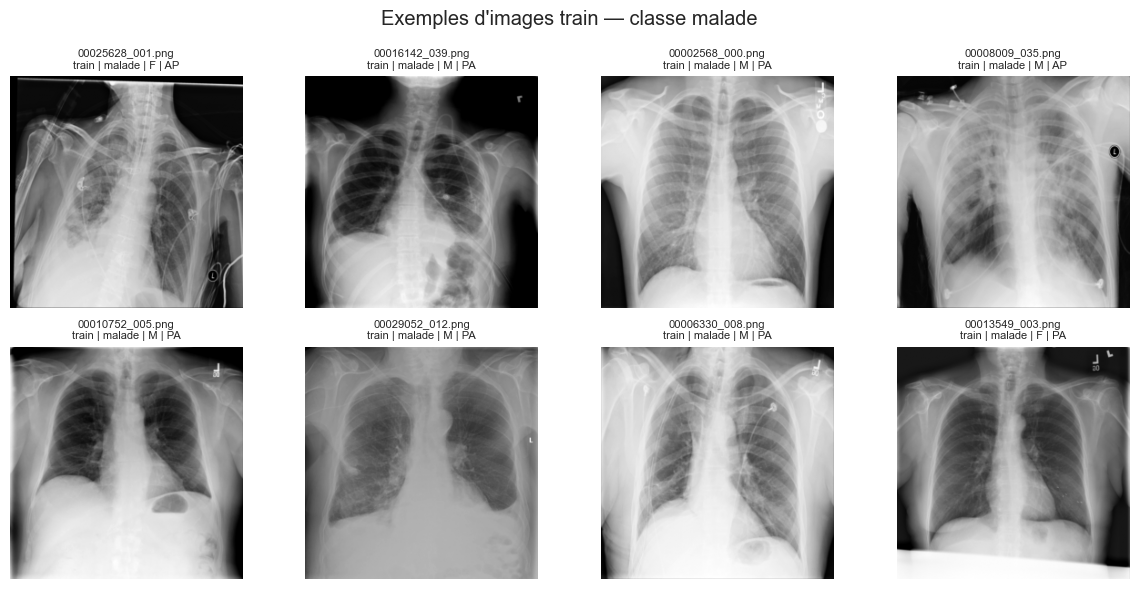

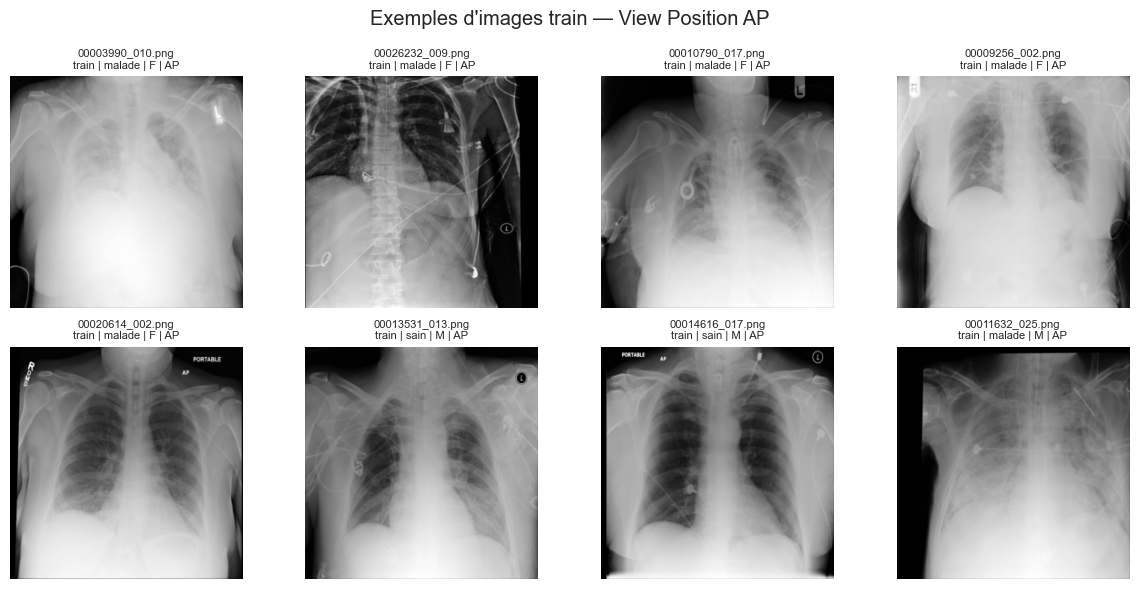

In [55]:
show_image_grid(
    df_img[(df_img['train_valid'] == 'train') & (df_img['label'] == 'malade')],
    title="Exemples d'images train — classe malade",
)

show_image_grid(
    df_img[(df_img['train_valid'] == 'train') & (df_img['View Position'] == 'AP')],
    title="Exemples d'images train — View Position AP",
)

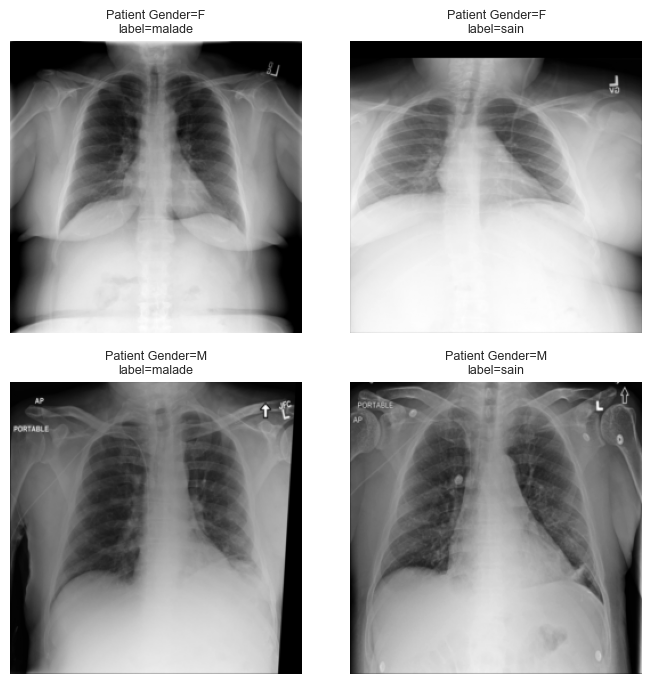

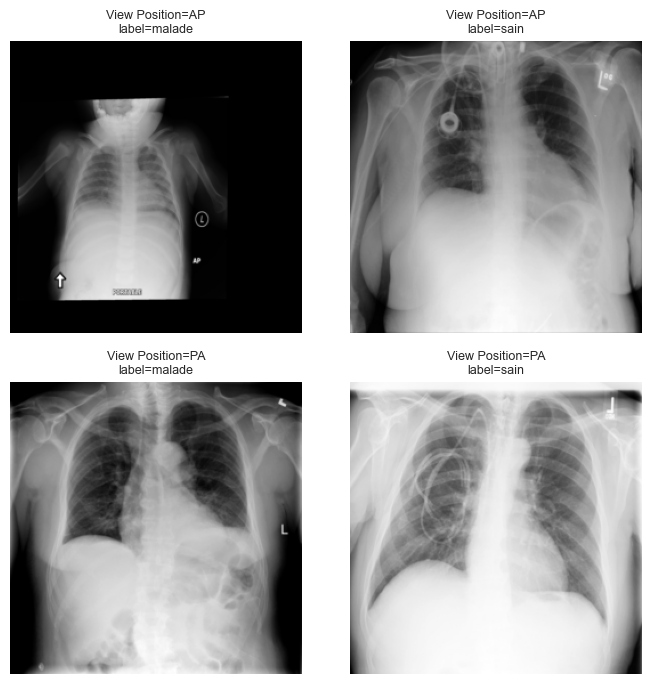

In [56]:
def stratified_image_examples(df, row_group, col_group, split='train',
                              samples_per_cell=1, random_state=RANDOM_STATE):
    """Grille d'images stratifiee par deux variables categorielles."""
    subset = df[df['train_valid'] == split].copy()
    row_values = sorted([x for x in subset[row_group].dropna().unique()])
    col_values = sorted([x for x in subset[col_group].dropna().unique()])
    nrows = len(row_values)
    ncols = len(col_values) * samples_per_cell
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows))
    axes = np.atleast_1d(axes).reshape(nrows, ncols)
    for ax in axes.ravel():
        ax.axis('off')
    for i, row_value in enumerate(row_values):
        for j, col_value in enumerate(col_values):
            cell_df = subset[(subset[row_group] == row_value) & (subset[col_group] == col_value)]
            if cell_df.empty:
                continue
            chosen = cell_df.sample(min(samples_per_cell, len(cell_df)), random_state=random_state)
            for k, (_, row) in enumerate(chosen.iterrows()):
                ax = axes[i, j * samples_per_cell + k]
                img = Image.open(resolve_image_path(row)).convert('L')
                ax.imshow(img, cmap='gray')
                ax.set_title(f'{row_group}={row_value}\n{col_group}={col_value}', fontsize=9)
    plt.tight_layout()
    plt.show()

stratified_image_examples(df_img, row_group='Patient Gender', col_group='label')
stratified_image_examples(df_img, row_group='View Position', col_group='label')

---
## 3. Analyse rapide des donnees : desequilibres et biais

*Conformement a la consigne, cette analyse est plus courte que le mi-projet mais doit montrer :*
- *les desequilibres de distribution (analyse univariee),*
- *les liens entre attributs sensibles et cible (analyse bivariee),*
- *des indices de biais ou de proxy susceptibles d'etre appris par le modele.*

### 3.1 Analyse univariee

L'analyse univariee revele les **desequilibres** dans les effectifs.
Un desequilibre n'est pas un biais en soi, mais il en est souvent le premier indicateur.

In [57]:
for variable in ['Patient Gender', 'View Position', 'age_group']:
    summary, mode_value = analyse_univariee(variable, df_patient)
    print(f'--- Analyse univariee de {variable} ---')
    display(summary)
    print('Mode:', mode_value)
    print()

--- Analyse univariee de Patient Gender ---


,effectif,frequence_pct
Patient Gender,,
M,816,54.4
F,684,45.6


Mode: M

--- Analyse univariee de View Position ---


,effectif,frequence_pct
View Position,,
PA,1215,81.0
AP,285,19.0


Mode: PA

--- Analyse univariee de age_group ---


,effectif,frequence_pct
age_group,,
41-60,669,44.60
<=40,526,35.07
>60,305,20.33


Mode: 41-60



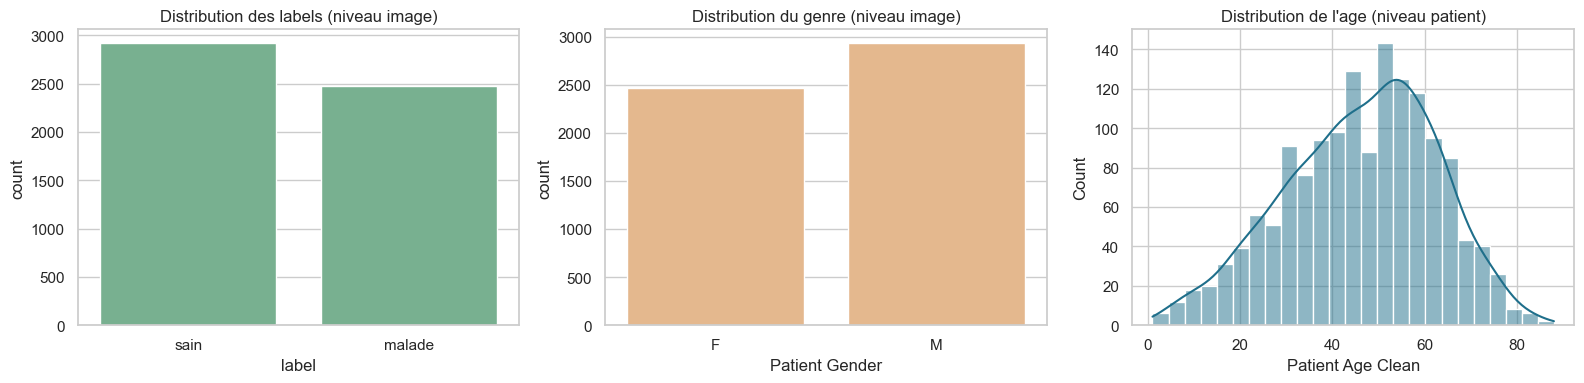

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df_img, x='label', order=['sain', 'malade'], ax=axes[0], color='#6fb98f')
axes[0].set_title('Distribution des labels (niveau image)')

sns.countplot(data=df_img, x='Patient Gender', order=['F', 'M'], ax=axes[1], color='#f2b880')
axes[1].set_title('Distribution du genre (niveau image)')

age_plot_df = df_patient.dropna(subset=['Patient Age Clean'])
sns.histplot(age_plot_df['Patient Age Clean'], bins=25, kde=True, ax=axes[2], color='#1f6f8b')
axes[2].set_title("Distribution de l'age (niveau patient)")

plt.tight_layout()
plt.show()

### 3.2 Analyse bivariee : attribut sensible x cible

L'analyse bivariee permet de detecter des **biais** : une difference de taux de pathologie
entre les groupes sensibles. On utilise :
- le **rapport de correlation eta²** pour le lien quali-quanti (Genre x Age),
- le **test du Chi²** pour les croisements quali-quali (Genre x has_finding, etc.),
- des **profils lignes** pour visualiser les differences de taux.

> **Rappel (TD2)** : Un biais peut avoir une explication (ex. Paradoxe de Simpson),
> mais il reste factuel. Un modele ML a tendance a **amplifier** les biais presents.

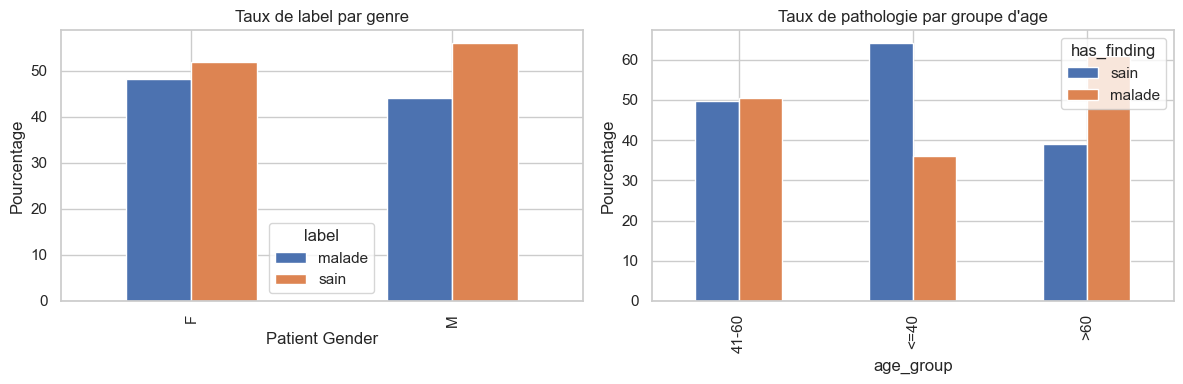

label,malade,sain
Patient Gender,,
F,48.11,51.89
M,44.09,55.91


has_finding,0,1
age_group,,
41-60,49.63,50.37
<=40,64.07,35.93
>60,39.02,60.98


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_ctab = pd.crosstab(df_img['Patient Gender'], df_img['label'], normalize='index').mul(100)
gender_ctab.plot(kind='bar', ax=axes[0], title='Taux de label par genre')
axes[0].set_ylabel('Pourcentage')
axes[0].legend(title='label')

age_ctab = pd.crosstab(df_patient['age_group'], df_patient['has_finding'], normalize='index').mul(100)
age_ctab.rename(columns={0: 'sain', 1: 'malade'}).plot(
    kind='bar', ax=axes[1], title='Taux de pathologie par groupe d\'age')
axes[1].set_ylabel('Pourcentage')
axes[1].legend(title='has_finding')

plt.tight_layout()
plt.show()

display(gender_ctab.round(2))
display(age_ctab.round(2))

In [60]:
# Rapports de correlation et tests du Chi²
eta_gender_age = rapport_correlation(df_patient, 'Patient Gender', 'Patient Age Clean')
eta_gender_visits = rapport_correlation(df_patient, 'Patient Gender', 'num_visits')

comparisons = [
    ('Patient Gender', 'has_finding'),
    ('Patient Gender', 'View Position'),
    ('Patient Gender', 'age_group'),
    ('View Position', 'has_finding'),
    ('age_group', 'has_finding'),
]

print(f'eta²(Genre, Age)        = {eta_gender_age:.4f}')
print(f'eta²(Genre, num_visits) = {eta_gender_visits:.4f}')
print()

for left, right in comparisons:
    contingency, profiles, chi2, p_value, dof = analyse_bivariee_quali(df_patient, left, right)
    print(f'--- {left} x {right} ---')
    display(contingency)
    display(profiles)
    sig = 'OUI (p < 0.05)' if p_value < 0.05 else 'NON (p >= 0.05)'
    print(f'Chi2={chi2:.4f}, p-value={p_value:.6g}, ddl={dof} --> Significatif ? {sig}')
    print()

eta²(Genre, Age)        = 0.0010
eta²(Genre, num_visits) = 0.0000

--- Patient Gender x has_finding ---


has_finding,0,1
Patient Gender,,
F,363,321
M,425,391


has_finding,0,1
Patient Gender,,
F,53.07,46.93
M,52.08,47.92


Chi2=0.1084, p-value=0.741928, ddl=1 --> Significatif ? NON (p >= 0.05)

--- Patient Gender x View Position ---


View Position,AP,PA
Patient Gender,,
F,121,563
M,164,652


...

has_finding,0,1
View Position,,
AP,32.98,67.02
PA,57.12,42.88


Chi2=52.9711, p-value=3.38487e-13, ddl=1 --> Significatif ? OUI (p < 0.05)

--- age_group x has_finding ---


has_finding,0,1
age_group,,
41-60,332,337
<=40,337,189
>60,119,186


has_finding,0,1
age_group,,
41-60,49.63,50.37
<=40,64.07,35.93
>60,39.02,60.98


Chi2=52.6826, p-value=3.63184e-12, ddl=2 --> Significatif ? OUI (p < 0.05)



In [61]:
# Prevalence des pathologies les plus frequentes par genre
all_labels = df_img['Finding Labels'].str.split('|').explode()
top_diseases = all_labels[all_labels != 'No Finding'].value_counts().head(8).index.tolist()

prevalence_rows = []
for disease in top_diseases:
    patient_flag = (
        df_img.assign(flag=df_img['Finding Labels'].str.contains(disease, regex=False))
        .groupby('Patient ID')
        .agg({'flag': 'max', 'Patient Gender': 'first'})
        .reset_index()
    )
    for gender in ['F', 'M']:
        rate = patient_flag.loc[patient_flag['Patient Gender'] == gender, 'flag'].mean() * 100
        prevalence_rows.append({'Pathologie': disease, 'Genre': gender, 'Prevalence (%)': rate})

df_prev = pd.DataFrame(prevalence_rows)
fig = px.bar(
    df_prev, x='Pathologie', y='Prevalence (%)', color='Genre', barmode='group',
    title='Prevalence des pathologies les plus frequentes par genre',
)
fig.update_layout(xaxis_tickangle=-40)
fig.show()

### 3.3 Interpretation de l'analyse descriptive

**Desequilibres observes :**
- **Genre** : le dataset est desequilibre en faveur des hommes.
  Ce desequilibre est classique dans les datasets medicaux et constitue un premier facteur de risque.
- **Age** : la distribution est concentree entre 40 et 70 ans, avec peu de patients jeunes.
  Les plus de 60 ans ont un taux de pathologie significativement plus eleve, ce qui est medicalement attendu.
- **View Position** : la repartition AP / PA n'est pas equilibree.
  C'est important car le ResNet18 peut inferer cette information directement depuis l'image.

**Biais detectes :**
- Le croisement **Genre x has_finding** revele une difference de taux de pathologie entre hommes et femmes.
  Si le test du Chi² est significatif (p < 0.05), ce biais est statistiquement reel.
- Le croisement **View Position x has_finding** peut egalement montrer un biais.
  La position AP est souvent associee a des patients alites, donc plus malades.
- La prevalence des pathologies specifiques differe entre genres, ce qui confirme le biais global.

> **Lien avec le modele :** Le ResNet18 peut retrouver le genre, l'age et la position de vue
> a partir de l'image seule (cf. slides du cours). Si un biais existe dans les labels,
> le modele risque de l'amplifier via ces proxies visuels.

---
## 4. Fairness des labels et analyse proxy (avant tout modele)

Avant d'entrainer le modele, on mesure le **biais intrinseque** present dans les labels
du dataset. En passant `y_pred = y_true`, on obtient les metriques de fairness sur les donnees
elles-memes (cf. TD1/TD2).

**Metriques utilisees :**
| Metrique | Signification | Ideal |
|---|---|---|
| **SPD** (Statistical Parity Difference) | Difference de taux de positifs entre groupes | 0 |
| **DIR** (Disparate Impact Ratio) | Ratio des taux de positifs (regle des 80%) | 1 |
| **EOD** (Equal Opportunity Difference) | Difference de TPR entre groupes | 0 |
| **AOD** (Average Odds Difference) | Moyenne des ecarts FPR et TPR | 0 |

In [62]:
label_gender_metrics = get_metrics(
    y_true=df_patient['has_finding'].to_numpy(),
    y_pred=df_patient['has_finding'].to_numpy(),
    prot_attr=df_patient['gender_binary'].to_numpy(),
    priv_group=PRIVILEGED_GENDER,
    pos_label=1,
)

label_age_metrics = get_metrics(
    y_true=df_patient['has_finding'].to_numpy(),
    y_pred=df_patient['has_finding'].to_numpy(),
    prot_attr=df_patient['age_binary'].to_numpy(),
    priv_group=PRIVILEGED_AGE,
    pos_label=1,
)

label_fairness_df = pd.DataFrame({
    'genre (M=priv)': label_gender_metrics,
    'age (>60=priv)': label_age_metrics,
}).round(4)

print('Metriques de fairness sur les LABELS (y_pred = y_true) :')
display(label_fairness_df)

Metriques de fairness sur les LABELS (y_pred = y_true) :


,genre (M=priv),age (>60=priv)
base_rate_truth,0.4747,0.4747
statistical_parity_difference,-0.0099,-0.1697
disparate_impact_ratio,0.9794,0.7218
base_rate_preds,0.4747,0.4747
equal_opportunity_difference,0.0000,0.0000
average_odds_difference,0.0000,0.0000
conditional_demographic_disparity,-0.0009,0.0654
smoothed_edf,0.0208,0.3601
df_bias_amplification,0.0000,0.0000
balanced_accuracy_score,1.0000,1.0000


In [63]:
# Analyse proxy : quelles variables sont correlees avec le genre ?
proxy_summary = pd.DataFrame([
    {'lien': 'Genre x Age', 'mesure': 'eta²',
     'valeur': rapport_correlation(df_patient, 'Patient Gender', 'Patient Age Clean')},
    {'lien': 'Genre x num_visits', 'mesure': 'eta²',
     'valeur': rapport_correlation(df_patient, 'Patient Gender', 'num_visits')},
    {'lien': 'Genre x View Position', 'mesure': 'chi2 p-value',
     'valeur': analyse_bivariee_quali(df_patient, 'Patient Gender', 'View Position')[3]},
    {'lien': 'Genre x age_group', 'mesure': 'chi2 p-value',
     'valeur': analyse_bivariee_quali(df_patient, 'Patient Gender', 'age_group')[3]},
    {'lien': 'View Position x target', 'mesure': 'chi2 p-value',
     'valeur': analyse_bivariee_quali(df_patient, 'View Position', 'has_finding')[3]},
])

print('Resume des liens proxy :')
display(proxy_summary)
print()
print('Interpretation : si une variable est fortement correlee avec le genre')
print('ET avec la cible, elle peut servir de proxy et transmettre le biais au modele,')
print('meme sans acces direct a l\'attribut sensible.')

Resume des liens proxy :


,lien,mesure,valeur
0,Genre x Age,eta²,9.505423e-04
1,Genre x num_visits,eta²,4.586623e-07
2,Genre x View Position,chi2 p-value,2.635871e-01
3,Genre x age_group,chi2 p-value,6.013357e-02
4,View Position x target,chi2 p-value,3.384872e-13



Interpretation : si une variable est fortement correlee avec le genre
ET avec la cible, elle peut servir de proxy et transmettre le biais au modele,
meme sans acces direct a l'attribut sensible.


---
## 5. Pre-processing : strategies de ponderation

Le classifieur impose utilise un `WeightedRandomSampler` qui s'appuie sur une colonne de poids
dans le CSV. C'est le **seul levier de pre-processing** compatible avec le pipeline.

On teste plusieurs strategies de ponderation (inspirees de TD4) :

| Strategie | Principe | Colonne |
|---|---|---|
| **Baseline** | Poids uniformes (1.0) | `WEIGHTS_BASELINE` |
| **Course** | Poids fournis par le cours | `WEIGHTS_COURSE` |
| **Class balanced** | Frequence inverse par classe | `WEIGHTS_CLASS_BALANCED` |
| **Gender Reweighing** | Reweighing AIF360 sur le genre | `WEIGHTS_GENDER_RW` |
| **Age Reweighing** | Reweighing AIF360 sur l'age | `WEIGHTS_AGE_RW` |
| **Gender x Label** | Frequence inverse par genre x label | `WEIGHTS_GENDER_LABEL` |
| **View x Label** | Frequence inverse par view position x label | `WEIGHTS_VIEW_LABEL` |

> **Pourquoi pas DisparateImpactRemover ?** Cette methode modifie les features tabulaires.
> Or ici le modele ne consomme que l'image : modifier les metadonnees n'aurait aucun effet.

In [64]:
def inverse_frequency_weights(df, group_cols):
    """Poids = frequence inverse du groupe. Plus un groupe est petit, plus il pese."""
    counts = df.groupby(group_cols)['Image Index'].transform('count')
    return normalize_weights(1.0 / counts)


def build_reweighing_weights(df, protected_col, privileged_value=1):
    """Reweighing AIF360 : ajuste les poids pour egaliser les taux de base entre groupes."""
    if not AIF360_PREPROCESSING_AVAILABLE:
        print(f'AIF360 non disponible, poids uniformes pour {protected_col}')
        return normalize_weights(np.ones(len(df)))

    rw_df = df[[protected_col, 'has_finding']].copy()
    rw_df['dummy_feature'] = 0

    dataset = StandardDataset(
        df=rw_df,
        label_name='has_finding',
        favorable_classes=[1],
        protected_attribute_names=[protected_col],
        privileged_classes=[[privileged_value]],
        categorical_features=[],
        features_to_keep=['dummy_feature', protected_col, 'has_finding'],
    )

    rw = Reweighing(
        unprivileged_groups=[{protected_col: 0}],
        privileged_groups=[{protected_col: privileged_value}],
    )
    dataset_rw = rw.fit_transform(dataset)
    return normalize_weights(dataset_rw.instance_weights)


# Calcul de toutes les strategies de ponderation
df_model = df_img.copy()
df_model['WEIGHTS_BASELINE'] = 1.0
df_model['WEIGHTS_COURSE'] = normalize_weights(
    pd.to_numeric(df_model['WEIGHTS'], errors='coerce').fillna(1.0)
)
df_model['WEIGHTS_CLASS_BALANCED'] = inverse_frequency_weights(df_model, ['label'])
df_model['WEIGHTS_GENDER_RW'] = build_reweighing_weights(
    df_model, 'gender_binary', privileged_value=PRIVILEGED_GENDER
)
df_model['WEIGHTS_AGE_RW'] = build_reweighing_weights(
    df_model, 'age_binary', privileged_value=PRIVILEGED_AGE
)
df_model['WEIGHTS_GENDER_LABEL'] = inverse_frequency_weights(df_model, ['Patient Gender', 'label'])
df_model['WEIGHTS_VIEW_LABEL'] = inverse_frequency_weights(df_model, ['View Position', 'label'])

# Sauvegarder le CSV enrichi
df_model.to_csv(EXPERIMENT_CSV, index=False)

weight_columns = [
    'WEIGHTS_BASELINE', 'WEIGHTS_COURSE', 'WEIGHTS_CLASS_BALANCED',
    'WEIGHTS_GENDER_RW', 'WEIGHTS_AGE_RW', 'WEIGHTS_GENDER_LABEL', 'WEIGHTS_VIEW_LABEL',
]

print('CSV enrichi sauvegarde dans :', EXPERIMENT_CSV)
display(df_model[['Image Index', 'label', 'Patient Gender', 'View Position', 'age_group'] + weight_columns].head())

CSV enrichi sauvegarde dans : metadata_experiments.csv


,Image Index,label,Patient Gender,View Position,age_group,WEIGHTS_BASELINE,WEIGHTS_COURSE,WEIGHTS_CLASS_BALANCED,WEIGHTS_GENDER_RW,WEIGHTS_AGE_RW,WEIGHTS_GENDER_LABEL,WEIGHTS_VIEW_LABEL
0,00000020_000.png,malade,M,PA,41-60,1.0,1.0,1.088687,1.041626,1.050151,1.043571,0.905410
1,00000020_001.png,malade,M,PA,41-60,1.0,1.0,1.088687,1.041626,1.050151,1.043571,0.905410
2,00000020_002.png,malade,M,PA,41-60,1.0,1.0,1.088687,1.041626,1.050151,1.043571,0.905410
3,00000026_000.png,malade,M,PA,>60,1.0,1.0,1.088687,1.041626,0.857111,1.043571,0.905410
4,00000082_000.png,sain,M,PA,41-60,1.0,1.0,0.924674,0.967172,0.961019,0.822999,0.708706


In [65]:
# Diagnostic des poids : statistiques descriptives
weight_diagnostics = []
for col in weight_columns:
    stats = df_model[col].describe()[['mean', 'std', 'min', 'max']].to_dict()
    stats['strategie'] = col.replace('WEIGHTS_', '')
    weight_diagnostics.append(stats)

weight_diagnostics_df = pd.DataFrame(weight_diagnostics).set_index('strategie').round(4)
display(weight_diagnostics_df)

# Verifier que les poids sont normalises (moyenne ~1)
print('\nVerification : la moyenne de chaque strategie doit etre ~1.0')
for col in weight_columns:
    print(f'  {col}: mean = {df_model[col].mean():.4f}')

,mean,std,min,max
strategie,,,,
BASELINE,1.0,0.0000,1.0000,1.0000
COURSE,1.0,0.0000,1.0000,1.0000
CLASS_BALANCED,1.0,0.0817,0.9247,1.0887
GENDER_RW,1.0,0.0402,0.9546,1.0421
AGE_RW,1.0,0.0823,0.8571,1.1650
GENDER_LABEL,1.0,0.1219,0.8230,1.1379
VIEW_LABEL,1.0,0.2780,0.7087,1.3650



Verification : la moyenne de chaque strategie doit etre ~1.0
  WEIGHTS_BASELINE: mean = 1.0000
  WEIGHTS_COURSE: mean = 1.0000
  WEIGHTS_CLASS_BALANCED: mean = 1.0000
  WEIGHTS_GENDER_RW: mean = 1.0000
  WEIGHTS_AGE_RW: mean = 1.0000
  WEIGHTS_GENDER_LABEL: mean = 1.0000
  WEIGHTS_VIEW_LABEL: mean = 1.0000


---
## 6. Entrainement du modele et prediction

`train_classifieur.py` reste **inchange**. Le notebook :
1. Ecrit un CSV enrichi avec les nouvelles colonnes de poids,
2. Lance `train_classifier(...)` pour chaque strategie,
3. Lance `pred_classifier(...)` pour exporter les logits,
4. Compare les sorties sur le split `valid`.

> **Important :** Mettre `RUN_TRAINING = True` dans la cellule de configuration
> pour lancer les entrainements (~20-60 min chacun).
> Une fois les checkpoints et preds.csv generes, remettre `RUN_TRAINING = False`
> pour eviter de relancer par erreur.

In [66]:
EXPERIMENTS = [
    {'run': 'baseline_unweighted',   'weights_col': 'WEIGHTS_BASELINE',       'active': True},
    {'run': 'course_weights',        'weights_col': 'WEIGHTS_COURSE',         'active': True},
    {'run': 'class_balanced',        'weights_col': 'WEIGHTS_CLASS_BALANCED', 'active': True},
    {'run': 'gender_rw',             'weights_col': 'WEIGHTS_GENDER_RW',      'active': True},
    {'run': 'age_rw',                'weights_col': 'WEIGHTS_AGE_RW',         'active': True},
    {'run': 'gender_label_balanced', 'weights_col': 'WEIGHTS_GENDER_LABEL',   'active': True},
    {'run': 'view_label_balanced',   'weights_col': 'WEIGHTS_VIEW_LABEL',     'active': True},
]

display(pd.DataFrame(EXPERIMENTS))

,run,weights_col,active
0,baseline_unweighted,WEIGHTS_BASELINE,True
1,course_weights,WEIGHTS_COURSE,True
2,class_balanced,WEIGHTS_CLASS_BALANCED,True
3,gender_rw,WEIGHTS_GENDER_RW,True
4,age_rw,WEIGHTS_AGE_RW,True
5,gender_label_balanced,WEIGHTS_GENDER_LABEL,True
6,view_label_balanced,WEIGHTS_VIEW_LABEL,True


In [67]:
def find_checkpoint(logdir):
    matches = sorted(glob.glob(str(Path(logdir) / '*.ckpt')))
    return matches[0] if matches else None


def run_single_experiment(run_name, weights_col, csv_path=EXPERIMENT_CSV):
    """Lance l'entrainement et/ou la prediction pour une experience."""
    logdir = LOG_ROOT / run_name
    preds_path = logdir / 'preds.csv'
    ckpt_path = find_checkpoint(logdir)

    should_train = RUN_TRAINING and (FORCE_RETRAIN or ckpt_path is None)
    should_predict = RUN_TRAINING and (FORCE_RETRAIN or not preds_path.exists())

    if should_train:
        ckpt_path, ckpt_score = train_classifier(
            logdir=str(logdir),
            datadir=str(DATA_DIR),
            csv=str(csv_path),
            weights_col=weights_col,
            max_epochs=MAX_EPOCHS,
        )
        print(f'{run_name} entraine — best score = {ckpt_score:.4f}')

    if should_predict:
        ckpt_path = ckpt_path or find_checkpoint(logdir)
        if ckpt_path is None:
            raise FileNotFoundError(f'Aucun checkpoint disponible pour {run_name}')
        pred_classifier(
            datadir=str(DATA_DIR),
            ckpt_path=str(ckpt_path),
            csv_in=str(csv_path),
            csv_out=str(preds_path),
        )
        print(f'{run_name} predictions exportees dans {preds_path}')

    return {
        'run': run_name,
        'weights_col': weights_col,
        'logdir': str(logdir),
        'ckpt_path': ckpt_path or find_checkpoint(logdir),
        'preds_path': str(preds_path),
        'preds_exists': preds_path.exists(),
    }


experiment_registry = []
for exp in EXPERIMENTS:
    if exp['active']:
        experiment_registry.append(run_single_experiment(exp['run'], exp['weights_col']))

experiment_registry_df = pd.DataFrame(experiment_registry)
display(experiment_registry_df)

# Afficher les experiences pretes vs manquantes
n_ready = experiment_registry_df['preds_exists'].sum()
n_total = len(experiment_registry_df)
print(f'\n{n_ready}/{n_total} experiences ont des predictions disponibles.')
if n_ready < n_total:
    print('Pour lancer les experiences manquantes, mettre RUN_TRAINING = True et re-executer.')

,run,weights_col,logdir,ckpt_path,preds_path,preds_exists
0,baseline_unweighted,WEIGHTS_BASELINE,expe_log/baseline_unweighted,expe_log/baseline_unweighted/best-val-loss.ckpt,expe_log/baseline_unweighted/preds.csv,True
1,course_weights,WEIGHTS_COURSE,expe_log/course_weights,expe_log/course_weights/best-val-loss.ckpt,expe_log/course_weights/preds.csv,True
2,class_balanced,WEIGHTS_CLASS_BALANCED,expe_log/class_balanced,expe_log/class_balanced/best-val-loss.ckpt,expe_log/class_balanced/preds.csv,True
3,gender_rw,WEIGHTS_GENDER_RW,expe_log/gender_rw,expe_log/gender_rw/best-val-loss.ckpt,expe_log/gender_rw/preds.csv,True
4,age_rw,WEIGHTS_AGE_RW,expe_log/age_rw,expe_log/age_rw/best-val-loss.ckpt,expe_log/age_rw/preds.csv,True
5,gender_label_balanced,WEIGHTS_GENDER_LABEL,expe_log/gender_label_balanced,expe_log/gender_label_balanced/best-val-loss.ckpt,expe_log/gender_label_balanced/preds.csv,True
6,view_label_balanced,WEIGHTS_VIEW_LABEL,expe_log/view_label_balanced,expe_log/view_label_balanced/best-val-loss.ckpt,expe_log/view_label_balanced/preds.csv,True



7/7 experiences ont des predictions disponibles.


---
## 7. Audit du modele sur les predictions

Cette section est inspiree des **TD1 et TD3** :
- **Performance globale** (balanced accuracy) par strategie de ponderation,
- **Fairness des predictions** (SPD, DIR, EOD, AOD) par attribut sensible,
- **Analyse par sous-groupes** : taux d'erreur, TPR, FPR par genre, age, view position,
- **Inspection d'images mal classees** : identifier les patterns d'erreur.

> **Point cle :** La balanced accuracy est la metrique de performance principale car elle
> compense le desequilibre de classes. Mais une bonne accuracy ne garantit pas la fairness.

In [68]:
def softmax_np(logits):
    logits = np.asarray(logits, dtype=float)
    logits = logits - logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)


def prepare_prediction_frame(df_pred):
    """Enrichit le dataframe de predictions avec les colonnes necessaires a l'audit."""
    df_eval = add_common_columns(df_pred)
    logit_cols = sorted(
        [col for col in df_eval.columns if col.startswith('preds_logit')],
        key=lambda col: int(col.replace('preds_logit', '')),
    )
    probs = softmax_np(df_eval[logit_cols].to_numpy())
    df_eval['score_malade'] = probs[:, POSITIVE_INDEX]
    df_eval['y_true'] = (df_eval['labels'] == POSITIVE_LABEL).astype(int)
    df_eval['y_pred'] = (df_eval['preds'] == POSITIVE_LABEL).astype(int)
    df_eval['error'] = (df_eval['y_true'] != df_eval['y_pred']).astype(int)
    return df_eval


def fairness_summary(y_true, y_pred, prot_attr, priv_group):
    metrics = get_metrics(
        y_true=np.asarray(y_true), y_pred=np.asarray(y_pred),
        prot_attr=np.asarray(prot_attr), priv_group=priv_group, pos_label=1,
    )
    return {
        'SPD': metrics['statistical_parity_difference'],
        'DIR': metrics['disparate_impact_ratio'],
        'EOD': metrics['equal_opportunity_difference'],
        'AOD': metrics['average_odds_difference'],
    }


def evaluate_run(df_pred, run_name, stage='raw', split_name=VALID_SPLIT_NAME,
                 y_pred_override=None):
    """Evalue une experience sur le split de validation."""
    df_eval = prepare_prediction_frame(df_pred)
    df_eval = df_eval[df_eval['train_valid'] == split_name].copy()
    y_true = df_eval['y_true'].to_numpy()
    y_pred = (df_eval['y_pred'].to_numpy() if y_pred_override is None
              else np.asarray(y_pred_override))

    gender_metrics = fairness_summary(y_true, y_pred, df_eval['gender_binary'], PRIVILEGED_GENDER)
    age_metrics = fairness_summary(y_true, y_pred, df_eval['age_binary'], PRIVILEGED_AGE)

    return {
        'run': run_name, 'stage': stage, 'split': split_name, 'n': len(df_eval),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
        'gender_SPD': gender_metrics['SPD'], 'gender_DIR': gender_metrics['DIR'],
        'gender_EOD': gender_metrics['EOD'], 'gender_AOD': gender_metrics['AOD'],
        'age_SPD': age_metrics['SPD'], 'age_DIR': age_metrics['DIR'],
        'age_EOD': age_metrics['EOD'], 'age_AOD': age_metrics['AOD'],
    }


def subgroup_report(df_eval, group_col):
    """Rapport detaille par sous-groupe (inspire de TD3)."""
    rows = []
    for group_value, group_df in df_eval.groupby(group_col):
        y_true = group_df['y_true'].to_numpy()
        y_pred = group_df['y_pred'].to_numpy()
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        tnr = tn / (tn + fp) if (tn + fp) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        fnr = fn / (fn + tp) if (fn + tp) else np.nan
        rows.append({
            group_col: group_value, 'n': len(group_df),
            'prevalence': group_df['y_true'].mean(),
            'taux_prediction_positive': group_df['y_pred'].mean(),
            'taux_erreur': (group_df['y_true'] != group_df['y_pred']).mean(),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'TPR': tpr, 'TNR': tnr, 'FPR': fpr, 'FNR': fnr,
        })
    return pd.DataFrame(rows).sort_values(group_col)


def plot_group_confusion_matrices(df_eval, group_col, title_prefix):
    groups = sorted(df_eval[group_col].dropna().unique())
    fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 4))
    axes = np.atleast_1d(axes)
    for ax, value in zip(axes, groups):
        group_df = df_eval[df_eval[group_col] == value]
        cm = confusion_matrix(group_df['y_true'], group_df['y_pred'], labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                    xticklabels=['sain', 'malade'], yticklabels=['sain', 'malade'])
        ax.set_title(f'{title_prefix} — {group_col}={value}')
        ax.set_xlabel('Prediction')
        ax.set_ylabel('Verite')
    plt.tight_layout()
    plt.show()

In [69]:
# Charger toutes les predictions disponibles et evaluer
available_predictions = {}
raw_results = []

for exp in EXPERIMENTS:
    if not exp['active']:
        continue
    preds_path = LOG_ROOT / exp['run'] / 'preds.csv'
    if preds_path.exists():
        df_pred = pd.read_csv(preds_path)
        available_predictions[exp['run']] = df_pred
        raw_results.append(evaluate_run(df_pred, exp['run'], stage='raw'))

raw_results_df = pd.DataFrame(raw_results)
if raw_results_df.empty:
    print('Aucun preds.csv disponible.')
    print('Mettez RUN_TRAINING=True ou reutilisez des runs deja presents.')
else:
    raw_results_df = raw_results_df.sort_values('balanced_accuracy', ascending=False).reset_index(drop=True)
    print(f'{len(raw_results_df)} experience(s) evaluee(s) :')
    display(raw_results_df.round(4))

7 experience(s) evaluee(s) :


,run,stage,split,n,balanced_accuracy,accuracy,gender_SPD,gender_DIR,gender_EOD,gender_AOD,age_SPD,age_DIR,age_EOD,age_AOD
0,class_balanced,raw,valid,1415,0.6909,0.6954,0.1200,1.3253,0.1043,0.0905,-0.0509,0.8903,-0.0254,-0.0582
1,gender_rw,raw,valid,1415,0.6765,0.6813,0.1196,1.3267,0.1051,0.0924,-0.0133,0.9693,0.0807,-0.0133
2,gender_label_balanced,raw,valid,1415,0.6711,0.6650,0.1378,1.2721,0.1111,0.1108,-0.1899,0.7360,-0.0888,-0.1891
3,baseline_unweighted,raw,valid,1415,0.6626,0.6721,0.1693,1.6078,0.1755,0.1458,-0.0419,0.8926,0.0543,-0.0410
4,age_rw,raw,valid,1415,0.6549,0.6686,0.1775,1.8113,0.1905,0.1556,0.0229,1.0807,0.1210,0.0244
5,course_weights,raw,valid,1415,0.6538,0.6650,0.2004,1.8301,0.2288,0.1797,-0.0461,0.8758,0.0323,-0.0465
6,view_label_balanced,raw,valid,1415,0.6025,0.5830,0.1685,1.2472,0.1245,0.1512,-0.0879,0.8940,-0.0254,-0.0872


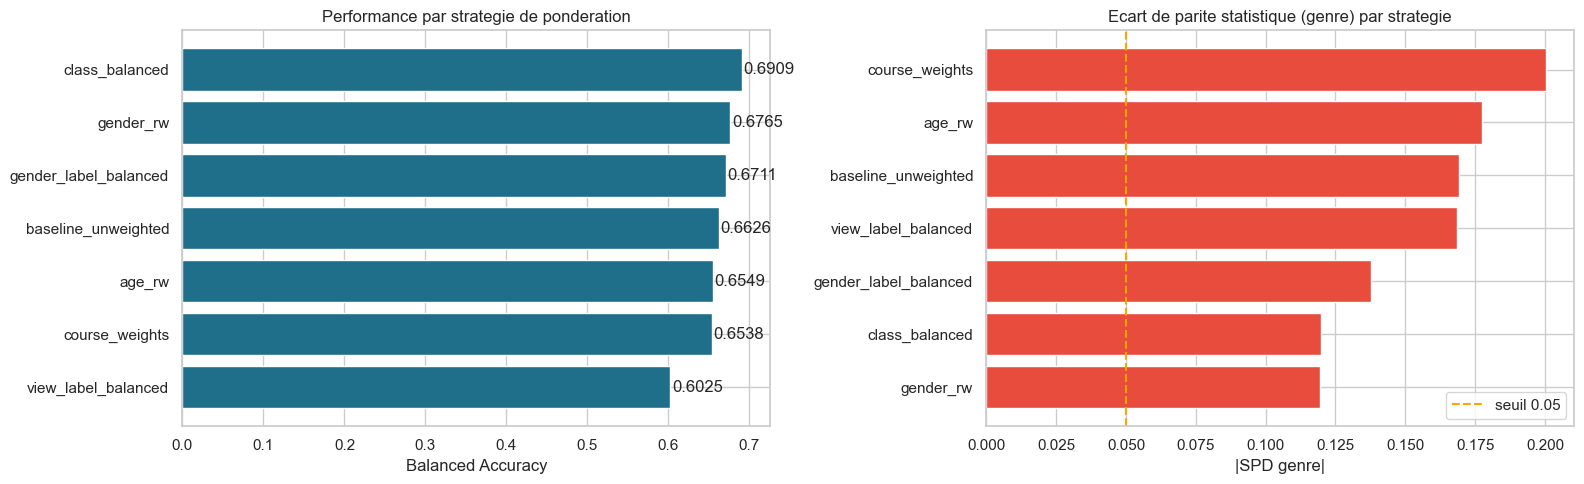

In [70]:
# Visualisation des performances et de la fairness par strategie de pre-processing
if not raw_results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Balanced accuracy
    raw_sorted = raw_results_df.sort_values('balanced_accuracy', ascending=True)
    axes[0].barh(raw_sorted['run'], raw_sorted['balanced_accuracy'], color='#1f6f8b')
    axes[0].set_xlabel('Balanced Accuracy')
    axes[0].set_title('Performance par strategie de ponderation')
    for i, (_, row) in enumerate(raw_sorted.iterrows()):
        axes[0].text(row['balanced_accuracy'] + 0.002, i, f"{row['balanced_accuracy']:.4f}", va='center')

    # |SPD genre|
    raw_sorted_spd = raw_results_df.sort_values('gender_SPD', key=lambda x: x.abs(), ascending=True)
    colors = ['#2ecc71' if abs(v) < 0.05 else '#e74c3c' for v in raw_sorted_spd['gender_SPD']]
    axes[1].barh(raw_sorted_spd['run'], raw_sorted_spd['gender_SPD'].abs(), color=colors)
    axes[1].set_xlabel('|SPD genre|')
    axes[1].set_title('Ecart de parite statistique (genre) par strategie')
    axes[1].axvline(x=0.05, color='orange', linestyle='--', label='seuil 0.05')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

=== Audit detaille de : class_balanced ===

--- Rapport par genre ---


,Patient Gender,n,prevalence,taux_prediction_positive,taux_erreur,balanced_accuracy,TPR,TNR,FPR,FNR
0,F,661,0.5068,0.4887,0.3056,0.6946,0.6806,0.7086,0.2914,0.3194
1,M,754,0.4257,0.3687,0.3037,0.6808,0.5763,0.7852,0.2148,0.4237



--- Rapport par groupe d'age ---


,age_group,n,prevalence,taux_prediction_positive,taux_erreur,balanced_accuracy,TPR,TNR,FPR,FNR
0,41-60,569,0.4991,0.4675,0.3058,0.6941,0.6620,0.7263,0.2737,0.3380
1,<=40,535,0.4374,0.3570,0.2860,0.6992,0.5812,0.8173,0.1827,0.4188
2,>60,310,0.4419,0.4645,0.3323,0.6659,0.6496,0.6821,0.3179,0.3504
3,Unknown,1,1.0000,0.0000,1.0000,0.0000,0.0000,NaN,NaN,1.0000



--- Rapport par View Position ---


,View Position,n,prevalence,taux_prediction_positive,taux_erreur,balanced_accuracy,TPR,TNR,FPR,FNR
0,AP,570,0.4877,0.5018,0.3228,0.6773,0.6835,0.6712,0.3288,0.3165
1,PA,845,0.4473,0.3728,0.2923,0.6965,0.5899,0.8030,0.1970,0.4101


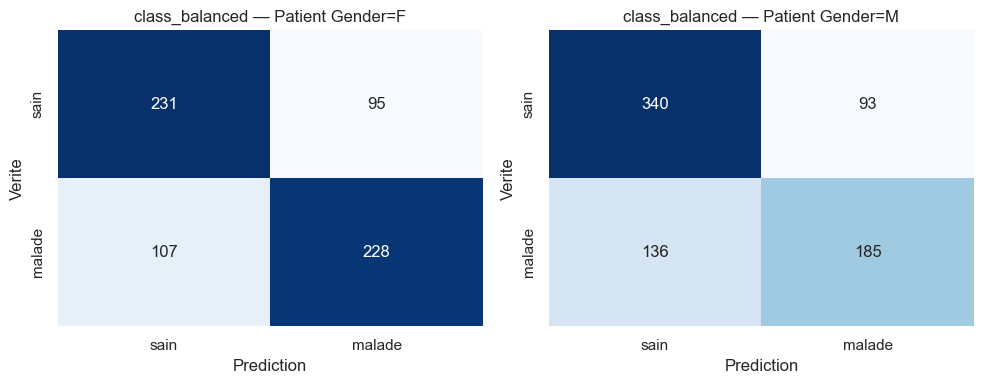

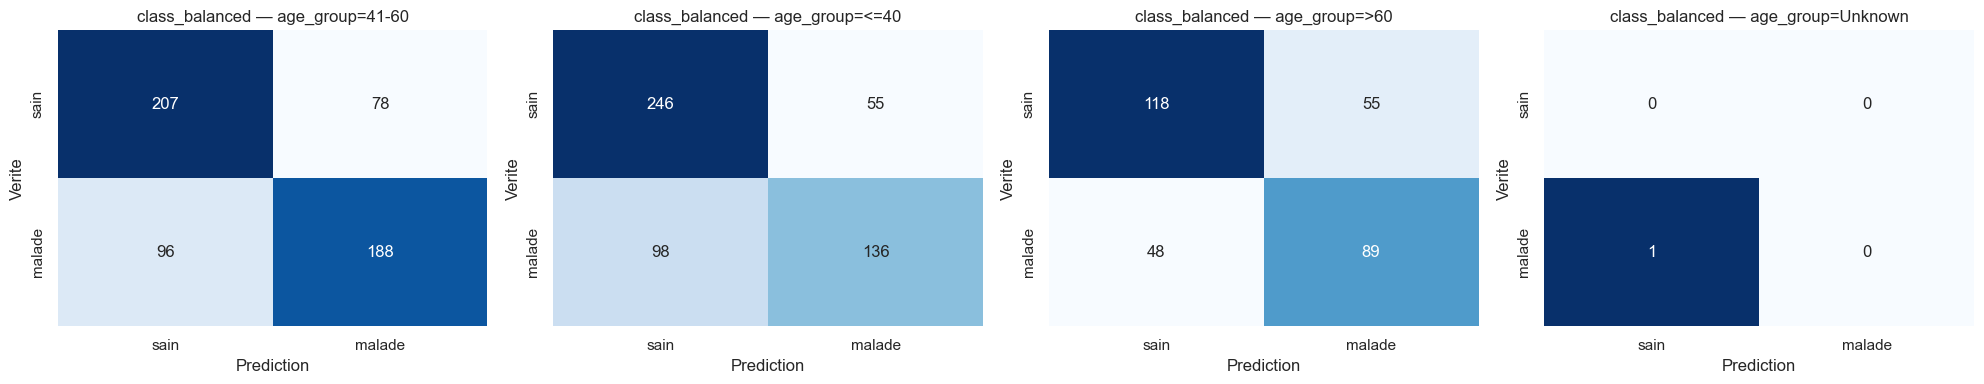

In [71]:
# Audit detaille : sous-groupes et matrices de confusion
if not raw_results_df.empty:
    # Choisir la meilleure strategie pour l'audit detaille
    baseline_name = 'baseline_unweighted'
    best_raw_name = raw_results_df.iloc[0]['run']
    audit_name = best_raw_name if best_raw_name in available_predictions else baseline_name

    if audit_name in available_predictions:
        audit_df = prepare_prediction_frame(available_predictions[audit_name])
        audit_df = audit_df[audit_df['train_valid'] == VALID_SPLIT_NAME].copy()

        print(f'=== Audit detaille de : {audit_name} ===')
        print()

        print('--- Rapport par genre ---')
        display(subgroup_report(audit_df, 'Patient Gender').round(4))
        print()

        print('--- Rapport par groupe d\'age ---')
        display(subgroup_report(audit_df, 'age_group').round(4))
        print()

        print('--- Rapport par View Position ---')
        display(subgroup_report(audit_df, 'View Position').round(4))

        plot_group_confusion_matrices(audit_df, 'Patient Gender', title_prefix=audit_name)
        plot_group_confusion_matrices(audit_df, 'age_group', title_prefix=audit_name)

### 7.1 Analyse des erreurs et inspection d'images

L'inspection visuelle des images mal classees permet de comprendre les patterns d'erreur du modele.
On regarde en particulier :
- les **faux negatifs** (malades predits sains) : les plus dangereux en contexte medical,
- les **cas proches de la frontiere** (score ~ 0.5) : les plus susceptibles d'etre corriges par post-processing.

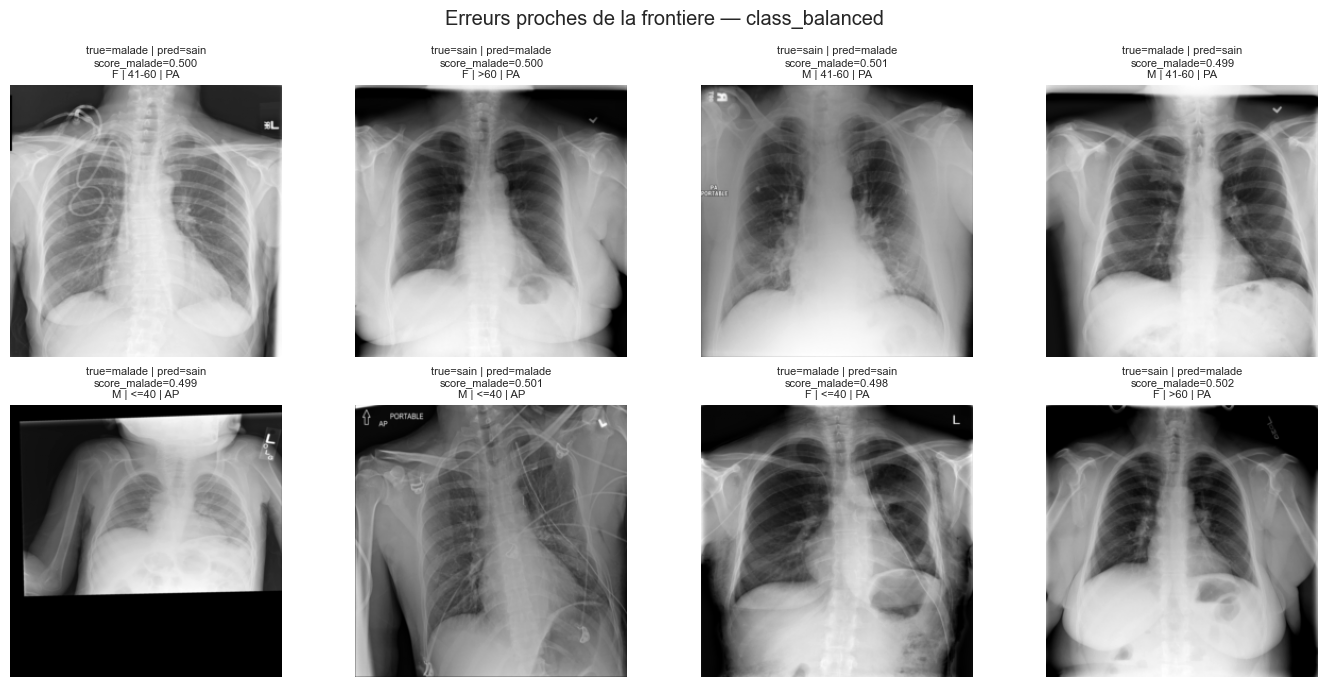

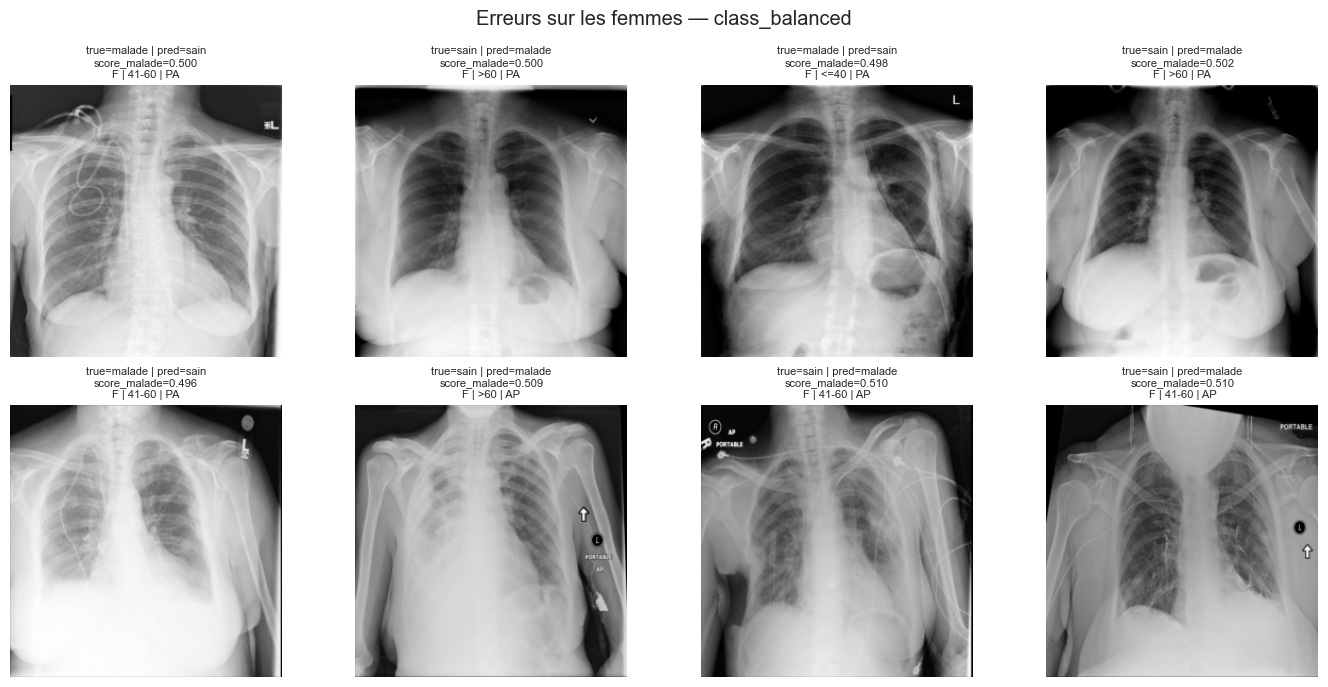

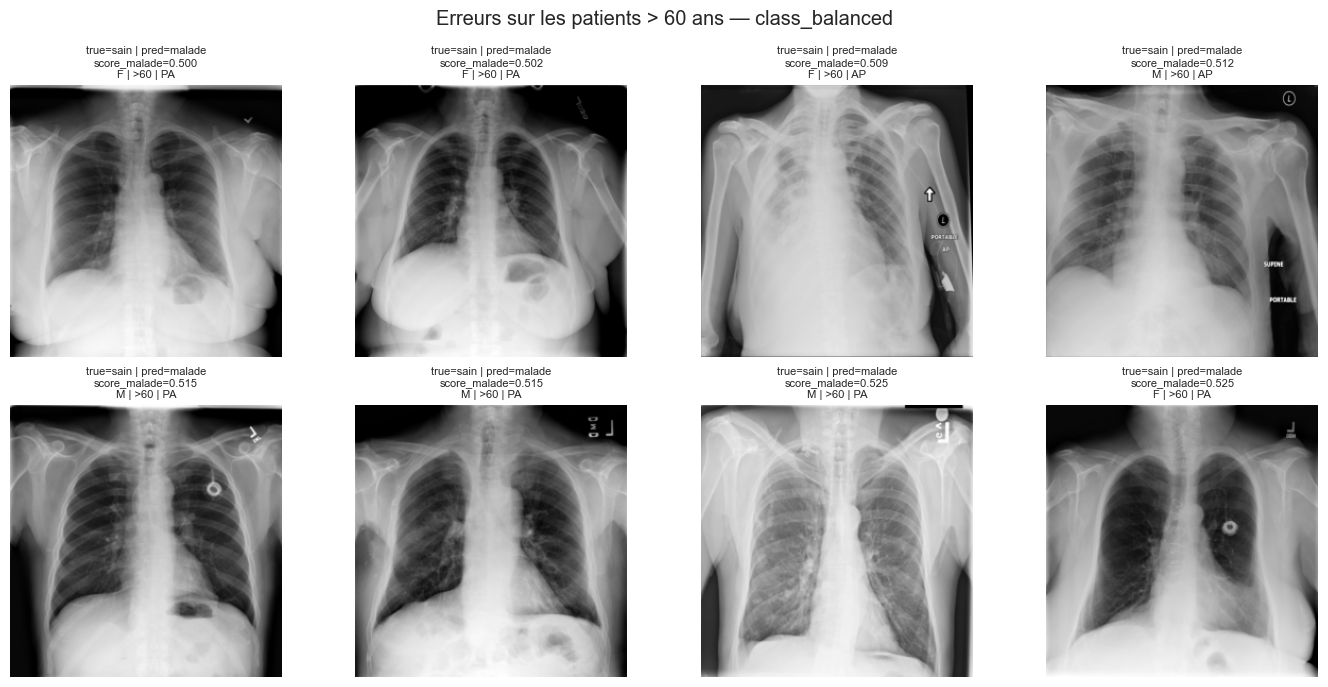

In [72]:
def show_error_gallery(df_eval, title, filter_mask=None, n=8, hardest=False):
    """Affiche une galerie d'images mal classees."""
    subset = df_eval.copy()
    if filter_mask is not None:
        subset = subset.loc[filter_mask].copy()
    subset = subset[subset['error'] == 1].copy()
    if subset.empty:
        print('Aucune erreur a afficher pour', title)
        return
    if hardest:
        subset['distance_to_boundary'] = np.abs(subset['score_malade'] - 0.5)
        subset = subset.sort_values('distance_to_boundary').head(n)
    else:
        subset = subset.head(n)

    rows = int(np.ceil(len(subset) / 4))
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3.5 * rows))
    axes = np.atleast_1d(axes).reshape(rows, 4)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, (_, row) in zip(axes.ravel(), subset.iterrows()):
        img = Image.open(resolve_image_path(row)).convert('L')
        ax.imshow(img, cmap='gray')
        title_text = (
            f"true={row['labels']} | pred={row['preds']}\n"
            f"score_malade={row['score_malade']:.3f}\n"
            f"{row['Patient Gender']} | {row['age_group']} | {row['View Position']}"
        )
        ax.set_title(title_text, fontsize=8)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

if not raw_results_df.empty and audit_name in available_predictions:
    show_error_gallery(audit_df, title=f'Erreurs proches de la frontiere — {audit_name}', hardest=True)
    show_error_gallery(
        audit_df,
        title=f'Erreurs sur les femmes — {audit_name}',
        filter_mask=(audit_df['Patient Gender'] == 'F'),
        hardest=True,
    )
    show_error_gallery(
        audit_df,
        title=f'Erreurs sur les patients > 60 ans — {audit_name}',
        filter_mask=(audit_df['age_group'] == '>60'),
        hardest=True,
    )

### 7.2 Interpretation de l'audit

**Ce qu'il faut verifier :**
1. **Le modele amplifie-t-il le biais ?** Comparer le SPD/DIR des predictions avec celui des labels.
   Si `|SPD_predictions| > |SPD_labels|`, le modele amplifie le biais (cf. `df_bias_amplification`).
2. **Quel groupe est le plus penalise ?** Regarder les TPR et FNR par sous-groupe.
   Un FNR plus eleve pour les femmes signifie qu'elles sont plus souvent diagnostiquees a tort comme saines.
3. **La View Position joue-t-elle un role ?** Si AP et PA ont des performances tres differentes,
   c'est un proxy visuel exploite par le modele.

> *Les resultats concrets seront analyses une fois les experiences executees.*

---
## 8. Post-processing sur les logits exportes

Le script de prediction sauvegarde les **logits par classe**. Cela permet de tester
plusieurs approches de post-processing sans re-entrainer le modele :

1. **Seuil global optimise** : recherche du seuil de classification qui maximise la balanced accuracy.
2. **Seuils differencies par groupe (genre)** : seuils distincts pour hommes et femmes,
   permettant d'egaliser les taux de classification.
3. **Reject Option Classification (AIF360, methode du TD4)** : algorithme de Kamiran et al. (2012)
   qui identifie une zone d'incertitude autour du seuil de decision et inverse les predictions
   dans cette zone pour les groupes defavorises. L'algorithme AIF360 optimise automatiquement
   le seuil et la marge pour satisfaire une contrainte de fairness (SPD ou Average Odds Difference).
4. **Calibrated Equalized Odds (AIF360, methode du TD4)** : algorithme de Pleiss et al. (NeurIPS 2017)
   qui ajuste les probabilites de prediction pour egaliser les taux d'erreur (FNR, FPR, ou combinaison)
   entre les groupes privilegies et non-privilegies.

> *Les methodes 3 et 4 utilisent directement les algorithmes de la librairie AIF360, comme etudie
> dans le TD4 (pre/post processing). Elles prennent en entree un `BinaryLabelDataset` avec les scores
> du modele et optimisent les parametres de post-processing via `fit()` puis `predict()`.*


In [73]:
# ===================== Fonctions de post-processing =====================

def apply_global_threshold(scores, threshold):
    return (np.asarray(scores) >= threshold).astype(int)


def apply_group_thresholds(scores, groups, threshold_map):
    scores = np.asarray(scores)
    groups = np.asarray(groups)
    preds = np.zeros(len(scores), dtype=int)
    for group_value, threshold in threshold_map.items():
        mask = groups == group_value
        preds[mask] = (scores[mask] >= threshold).astype(int)
    return preds


# ---------- Fonctions AIF360 (comme dans TD4) ----------

def build_aif360_dataset(df_eval, label_col='y_true',
                         protected_col='gender_binary',
                         privileged_value=1):
    """Construit un BinaryLabelDataset AIF360 a partir du dataframe de prediction.
    C'est l'objet requis par les algorithmes de post-processing d'AIF360
    (RejectOptionClassification, CalibratedEqOddsPostprocessing).
    """
    aif_df = df_eval[[protected_col, label_col]].copy()
    aif_df = aif_df.rename(columns={label_col: 'label'})
    aif_df = aif_df.reset_index(drop=True)

    dataset = BinaryLabelDataset(
        df=aif_df,
        label_names=['label'],
        protected_attribute_names=[protected_col],
        favorable_label=1.0,
        unfavorable_label=0.0,
    )
    return dataset


def apply_aif360_reject_option(df_eval, protected_col='gender_binary',
                                privileged_value=1,
                                metric_name="Statistical parity difference",
                                metric_ub=0.05, metric_lb=-0.05):
    """Reject Option Classification via AIF360 (methode du TD4).

    L'algorithme de la librairie AIF360 cherche automatiquement le meilleur
    seuil de classification et la meilleure marge (ROC_margin) pour satisfaire
    les contraintes de fairness donnees (metric_ub, metric_lb).
    Ref : Kamiran et al., 'Decision Theory for Discrimination-Aware Classification', 2012.
    """
    unprivileged_groups = [{protected_col: 0}]
    privileged_groups = [{protected_col: privileged_value}]

    # Dataset verite terrain
    gt_dataset = build_aif360_dataset(df_eval, 'y_true', protected_col, privileged_value)

    # Dataset predit : on copie la verite, puis on applique les scores et un seuil initial
    pred_dataset = gt_dataset.copy(deepcopy=True)
    scores = df_eval['score_malade'].to_numpy().reshape(-1, 1)
    pred_dataset.scores = scores
    fav_inds = scores.ravel() >= 0.5
    pred_dataset.labels[fav_inds] = pred_dataset.favorable_label
    pred_dataset.labels[~fav_inds] = pred_dataset.unfavorable_label

    ROC = RejectOptionClassification(
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
        low_class_thresh=0.01,
        high_class_thresh=0.99,
        num_class_thresh=100,
        num_ROC_margin=50,
        metric_name=metric_name,
        metric_ub=metric_ub,
        metric_lb=metric_lb,
    )
    ROC = ROC.fit(gt_dataset, pred_dataset)

    print(f"  [AIF360 ROC] Seuil optimal = {ROC.classification_threshold:.4f}, "
          f"Marge ROC = {ROC.ROC_margin:.4f}")

    result_dataset = ROC.predict(pred_dataset)
    return result_dataset.labels.ravel().astype(int), ROC


def apply_aif360_calibrated_eq_odds(df_eval, protected_col='gender_binary',
                                     privileged_value=1,
                                     cost_constraint='fnr'):
    """Calibrated Equalized Odds via AIF360 (methode du TD4).

    L'algorithme d'AIF360 calibre les probabilites pour egaliser les taux
    d'erreur entre les groupes. Trois contraintes de cout sont possibles :
    - 'fnr' : egalise les taux de faux negatifs generalises
    - 'fpr' : egalise les taux de faux positifs generalises
    - 'weighted' : combinaison ponderee des deux
    Ref : Pleiss et al., 'On Fairness and Calibration', NeurIPS 2017.
    """
    unprivileged_groups = [{protected_col: 0}]
    privileged_groups = [{protected_col: privileged_value}]

    gt_dataset = build_aif360_dataset(df_eval, 'y_true', protected_col, privileged_value)

    pred_dataset = gt_dataset.copy(deepcopy=True)
    scores = df_eval['score_malade'].to_numpy().reshape(-1, 1)
    pred_dataset.scores = scores
    fav_inds = scores.ravel() >= 0.5
    pred_dataset.labels[fav_inds] = pred_dataset.favorable_label
    pred_dataset.labels[~fav_inds] = pred_dataset.unfavorable_label

    cpp = CalibratedEqOddsPostprocessing(
        privileged_groups=privileged_groups,
        unprivileged_groups=unprivileged_groups,
        cost_constraint=cost_constraint,
        seed=42,
    )
    cpp = cpp.fit(gt_dataset, pred_dataset)

    result_dataset = cpp.predict(pred_dataset)
    return result_dataset.labels.ravel().astype(int), cpp


def objective_score(y_true, y_pred, groups, privileged_value=1,
                    fairness_weight=0.25, tolerance_floor=None):
    """Fonction objectif combinant performance et fairness."""
    fairness = fairness_summary(y_true, y_pred, groups, privileged_value)
    bacc = balanced_accuracy_score(y_true, y_pred)
    penalty = 0.0
    if tolerance_floor is not None and bacc < tolerance_floor:
        penalty = 10 * (tolerance_floor - bacc)
    obj = -bacc + fairness_weight * abs(fairness['SPD']) + 0.5 * fairness_weight * abs(fairness['EOD']) + penalty
    return bacc, fairness, obj


In [74]:
# ===================== Recherche des meilleurs parametres =====================

def search_global_threshold(df_eval, group_col='gender_binary', grid=None):
    grid = np.linspace(0.05, 0.95, 37) if grid is None else np.asarray(grid)
    y_true = df_eval['y_true'].to_numpy()
    scores = df_eval['score_malade'].to_numpy()
    groups = df_eval[group_col].to_numpy()
    rows = []
    for threshold in grid:
        y_pred = apply_global_threshold(scores, threshold)
        bacc, fairness, obj = objective_score(y_true, y_pred, groups)
        rows.append({
            'threshold': threshold, 'balanced_accuracy': bacc,
            'accuracy': accuracy_score(y_true, y_pred),
            'SPD': fairness['SPD'], 'DIR': fairness['DIR'],
            'EOD': fairness['EOD'], 'objective': obj,
        })
    return pd.DataFrame(rows).sort_values(['objective', 'balanced_accuracy'], ascending=[True, False])


def search_group_thresholds(df_eval, group_col='gender_binary', grid=None, tolerance=0.03):
    grid = np.linspace(0.10, 0.90, 17) if grid is None else np.asarray(grid)
    y_true = df_eval['y_true'].to_numpy()
    scores = df_eval['score_malade'].to_numpy()
    groups = df_eval[group_col].to_numpy()
    base_bacc = balanced_accuracy_score(y_true, df_eval['y_pred'].to_numpy())
    rows = []
    for th0 in grid:
        for th1 in grid:
            y_pred = apply_group_thresholds(scores, groups, {0: th0, 1: th1})
            bacc, fairness, obj = objective_score(
                y_true, y_pred, groups, tolerance_floor=base_bacc - tolerance)
            rows.append({
                'threshold_F': th0, 'threshold_M': th1,
                'balanced_accuracy': bacc, 'accuracy': accuracy_score(y_true, y_pred),
                'SPD': fairness['SPD'], 'DIR': fairness['DIR'],
                'EOD': fairness['EOD'], 'objective': obj,
            })
    return pd.DataFrame(rows).sort_values(['objective', 'balanced_accuracy'], ascending=[True, False])


In [75]:
# ===================== Application du post-processing =====================

def select_best_pre_run(results_df, baseline_run='baseline_unweighted', tolerance=0.03):
    """Selectionne la meilleure strategie de pre-processing :
    celle qui minimise l'ecart de fairness sans trop perdre en accuracy."""
    baseline_row = results_df[results_df['run'] == baseline_run]
    baseline_bacc = (baseline_row['balanced_accuracy'].iloc[0]
                     if not baseline_row.empty else results_df['balanced_accuracy'].max())
    candidates = results_df[results_df['run'] != baseline_run].copy()
    if candidates.empty:
        return baseline_run
    candidates['fairness_gap'] = candidates['gender_SPD'].abs() + candidates['age_SPD'].abs()
    eligible = candidates[candidates['balanced_accuracy'] >= baseline_bacc - tolerance]
    if eligible.empty:
        eligible = candidates
    return eligible.sort_values(['fairness_gap', 'balanced_accuracy'], ascending=[True, False]).iloc[0]['run']


post_rows = []
search_tables = {}

if not raw_results_df.empty:
    baseline_run = 'baseline_unweighted'
    best_pre_run = select_best_pre_run(raw_results_df, baseline_run=baseline_run)
    print(f'Meilleure strategie de pre-processing selectionnee : {best_pre_run}')
    print()

    candidate_runs = list(dict.fromkeys(
        [run for run in [baseline_run, best_pre_run] if run in available_predictions]
    ))

    for run_name in candidate_runs:
        df_eval = prepare_prediction_frame(available_predictions[run_name])
        df_eval = df_eval[df_eval['train_valid'] == VALID_SPLIT_NAME].copy()

        # Raw (sans post-processing)
        post_rows.append(evaluate_run(available_predictions[run_name], run_name, stage='raw'))

        # ------------------------------------------------------------------
        # 1. Seuil global (approche manuelle)
        # ------------------------------------------------------------------
        global_table = search_global_threshold(df_eval)
        best_global = global_table.iloc[0]
        global_pred = apply_global_threshold(df_eval['score_malade'], best_global['threshold'])
        post_rows.append(evaluate_run(
            available_predictions[run_name], run_name,
            stage=f"seuil_global_{best_global['threshold']:.2f}",
            y_pred_override=global_pred,
        ))
        search_tables[(run_name, 'seuil_global')] = global_table

        # ------------------------------------------------------------------
        # 2. Seuils par groupe genre (approche manuelle)
        # ------------------------------------------------------------------
        group_table = search_group_thresholds(df_eval)
        best_group = group_table.iloc[0]
        group_pred = apply_group_thresholds(
            df_eval['score_malade'], df_eval['gender_binary'],
            {0: best_group['threshold_F'], 1: best_group['threshold_M']},
        )
        post_rows.append(evaluate_run(
            available_predictions[run_name], run_name,
            stage=f"seuils_genre_F{best_group['threshold_F']:.2f}_M{best_group['threshold_M']:.2f}",
            y_pred_override=group_pred,
        ))
        search_tables[(run_name, 'seuils_genre')] = group_table

        # ------------------------------------------------------------------
        # 3. Reject Option Classification via AIF360 (methode TD4)
        # ------------------------------------------------------------------
        print(f'\n--- AIF360 RejectOptionClassification pour {run_name} ---')
        try:
            roc_pred, roc_model = apply_aif360_reject_option(
                df_eval, protected_col='gender_binary',
                privileged_value=PRIVILEGED_GENDER,
                metric_name="Statistical parity difference",
                metric_ub=0.05, metric_lb=-0.05,
            )
            post_rows.append(evaluate_run(
                available_predictions[run_name], run_name,
                stage='AIF360_ROC_SPD',
                y_pred_override=roc_pred,
            ))
        except Exception as e:
            print(f"  Erreur ROC (SPD) : {e}")

        # ROC avec Average odds difference
        try:
            roc_pred_aod, _ = apply_aif360_reject_option(
                df_eval, protected_col='gender_binary',
                privileged_value=PRIVILEGED_GENDER,
                metric_name="Average odds difference",
                metric_ub=0.05, metric_lb=-0.05,
            )
            post_rows.append(evaluate_run(
                available_predictions[run_name], run_name,
                stage='AIF360_ROC_AOD',
                y_pred_override=roc_pred_aod,
            ))
        except Exception as e:
            print(f"  Erreur ROC (AOD) : {e}")

        # ------------------------------------------------------------------
        # 4. Calibrated Equalized Odds via AIF360 (methode TD4)
        # ------------------------------------------------------------------
        for cost in ['fnr', 'fpr', 'weighted']:
            print(f'\n--- AIF360 CalibratedEqOdds ({cost}) pour {run_name} ---')
            try:
                ceqo_pred, ceqo_model = apply_aif360_calibrated_eq_odds(
                    df_eval, protected_col='gender_binary',
                    privileged_value=PRIVILEGED_GENDER,
                    cost_constraint=cost,
                )
                post_rows.append(evaluate_run(
                    available_predictions[run_name], run_name,
                    stage=f'AIF360_CalibratedEqOdds_{cost}',
                    y_pred_override=ceqo_pred,
                ))
            except Exception as e:
                print(f"  Erreur CalibratedEqOdds ({cost}) : {e}")

    post_results_df = pd.DataFrame(post_rows)
    print('\nResultats du post-processing :')
    display(post_results_df.round(4))
else:
    post_results_df = pd.DataFrame()
    print("Pas de predictions disponibles pour le post-processing.")


Meilleure strategie de pre-processing selectionnee : gender_rw



/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))



--- AIF360 RejectOptionClassification pour baseline_unweighted ---
  [AIF360 ROC] Seuil optimal = 0.0892, Marge ROC = 0.0000
  [AIF360 ROC] Seuil optimal = 0.0991, Marge ROC = 0.0000

--- AIF360 CalibratedEqOdds (fnr) pour baseline_unweighted ---

--- AIF360 CalibratedEqOdds (fpr) pour baseline_unweighted ---

--- AIF360 CalibratedEqOdds (weighted) pour baseline_unweighted ---


/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))



--- AIF360 RejectOptionClassification pour gender_rw ---
  [AIF360 ROC] Seuil optimal = 0.1585, Marge ROC = 0.0000
  [AIF360 ROC] Seuil optimal = 0.2476, Marge ROC = 0.0000

--- AIF360 CalibratedEqOdds (fnr) pour gender_rw ---

--- AIF360 CalibratedEqOdds (fpr) pour gender_rw ---

--- AIF360 CalibratedEqOdds (weighted) pour gender_rw ---

Resultats du post-processing :


/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))


,run,stage,split,n,balanced_accuracy,accuracy,gender_SPD,gender_DIR,gender_EOD,gender_AOD,age_SPD,age_DIR,age_EOD,age_AOD
0,baseline_unweighted,raw,valid,1415,0.6626,0.6721,0.1693,1.6078,0.1755,0.1458,-0.0419,0.8926,0.0543,-0.0410
1,baseline_unweighted,seuil_global_0.35,valid,1415,0.6846,0.6834,0.1431,1.3279,0.1226,0.1144,-0.0744,0.8674,0.0006,-0.0767
2,baseline_unweighted,seuils_genre_F0.40_M0.30,valid,1415,0.6766,0.6742,0.0189,1.0370,0.0155,-0.0083,-0.0412,0.9253,0.0195,-0.0444
3,baseline_unweighted,AIF360_ROC_SPD,valid,1415,0.5211,0.4869,0.0483,1.0511,0.0004,0.0425,-0.0283,0.9714,-0.0116,-0.0278
4,baseline_unweighted,AIF360_ROC_AOD,valid,1415,0.5289,0.4954,0.0555,1.0596,0.0035,0.0484,-0.0369,0.9626,-0.0135,-0.0361
5,baseline_unweighted,AIF360_CalibratedEqOdds_fnr,valid,1415,0.6040,0.5951,0.7215,3.5905,0.5576,0.7003,-0.0462,0.9291,0.0518,-0.0422
6,baseline_unweighted,AIF360_CalibratedEqOdds_fpr,valid,1415,0.6243,0.6410,0.3497,4.5628,0.4559,0.3391,-0.0411,0.8601,0.0654,-0.0373
7,baseline_unweighted,AIF360_CalibratedEqOdds_weighted,valid,1415,0.6603,0.6707,0.1905,1.7404,0.2036,0.1679,-0.0440,0.8844,0.0462,-0.0436
8,gender_rw,raw,valid,1415,0.6765,0.6813,0.1196,1.3267,0.1051,0.0924,-0.0133,0.9693,0.0807,-0.0133
9,gender_rw,seuil_global_0.40,valid,1415,0.6888,0.6862,0.1114,1.2374,0.0819,0.0814,-0.0757,0.8697,0.0111,-0.0770


In [76]:
# Visualisation du compromis fairness / performance
if not post_results_df.empty:
    final_compare = post_results_df.copy()
    final_compare['methode'] = final_compare['run'] + ' | ' + final_compare['stage']
    final_compare['abs_gender_SPD'] = final_compare['gender_SPD'].abs()
    final_compare['abs_gender_EOD'] = final_compare['gender_EOD'].abs()

    # Scatter plot : balanced accuracy vs |SPD genre|
    fig = px.scatter(
        final_compare, x='abs_gender_SPD', y='balanced_accuracy',
        color='run', symbol='stage', text='methode',
        hover_data=['gender_DIR', 'gender_EOD', 'age_SPD', 'age_DIR'],
        title='Compromis fairness (|SPD genre|) vs performance (balanced accuracy)',
        labels={'abs_gender_SPD': '|SPD genre| (plus bas = plus juste)',
                'balanced_accuracy': 'Balanced Accuracy'},
    )
    fig.update_traces(textposition='top center', textfont_size=8)
    fig.show()

    # Tableau tri par fairness
    print('\nClassement par fairness (|SPD genre| croissant) :')
    display(final_compare.sort_values(['abs_gender_SPD', 'balanced_accuracy'],
                                       ascending=[True, False])[
        ['methode', 'balanced_accuracy', 'gender_SPD', 'gender_DIR',
         'gender_EOD', 'age_SPD', 'age_DIR']
    ].round(4))


Classement par fairness (|SPD genre| croissant) :


,methode,balanced_accuracy,gender_SPD,gender_DIR,gender_EOD,age_SPD,age_DIR
10,gender_rw | seuils_genre_F0.45_M0.35,0.6841,-0.0088,0.9837,-0.0222,-0.0658,0.8879
2,baseline_unweighted | seuils_genre_F0.40_M0.30,0.6766,0.0189,1.0370,0.0155,-0.0412,0.9253
11,gender_rw | AIF360_ROC_SPD,0.5553,0.0465,1.0523,0.0165,-0.0966,0.9021
3,baseline_unweighted | AIF360_ROC_SPD,0.5211,0.0483,1.0511,0.0004,-0.0283,0.9714
4,baseline_unweighted | AIF360_ROC_AOD,0.5289,0.0555,1.0596,0.0035,-0.0369,0.9626
12,gender_rw | AIF360_ROC_AOD,0.6258,0.0646,1.0901,0.0325,-0.1578,0.8188
9,gender_rw | seuil_global_0.40,0.6888,0.1114,1.2374,0.0819,-0.0757,0.8697
8,gender_rw | raw,0.6765,0.1196,1.3267,0.1051,-0.0133,0.9693
1,baseline_unweighted | seuil_global_0.35,0.6846,0.1431,1.3279,0.1226,-0.0744,0.8674
0,baseline_unweighted | raw,0.6626,0.1693,1.6078,0.1755,-0.0419,0.8926


In [77]:
# Afficher les grilles de recherche pour les meilleures combinaisons
if search_tables:
    for key, table in search_tables.items():
        print(f'\n--- Grille de recherche : {key} (top 10) ---')
        display(table.head(10).round(4))


--- Grille de recherche : ('baseline_unweighted', 'seuil_global') (top 10) ---


,threshold,balanced_accuracy,accuracy,SPD,DIR,EOD,objective
12,0.350,0.6846,0.6834,0.1431,1.3279,0.1226,-0.6335
13,0.375,0.6797,0.6806,0.1422,1.3481,0.1423,-0.6264
14,0.400,0.6785,0.6813,0.1515,1.4009,0.1557,-0.6212
16,0.450,0.6782,0.6841,0.1544,1.4621,0.1514,-0.6207
11,0.325,0.6760,0.6721,0.1595,1.3416,0.1305,-0.6198
15,0.425,0.6734,0.6777,0.1531,1.4291,0.1537,-0.6160
10,0.300,0.6648,0.6580,0.1535,1.3007,0.1140,-0.6122
17,0.475,0.6693,0.6770,0.1539,1.4981,0.1498,-0.6121
9,0.275,0.6549,0.6445,0.1557,1.2789,0.1093,-0.6023
18,0.500,0.6626,0.6721,0.1693,1.6078,0.1755,-0.5983



--- Grille de recherche : ('baseline_unweighted', 'seuils_genre') (top 10) ---


,threshold_F,threshold_M,balanced_accuracy,accuracy,SPD,DIR,EOD,objective
106,0.40,0.30,0.6766,0.6742,0.0189,1.0370,0.0155,-0.6699
141,0.50,0.35,0.6737,0.6770,0.0115,1.0263,-0.0207,-0.6683
124,0.45,0.35,0.6815,0.6834,0.0523,1.1199,0.0330,-0.6643
123,0.45,0.30,0.6730,0.6721,-0.0220,0.9570,-0.0293,-0.6639
158,0.55,0.35,0.6718,0.6763,-0.0233,0.9465,-0.0565,-0.6589
159,0.55,0.40,0.6653,0.6721,0.0350,1.0927,0.0213,-0.6538
107,0.40,0.35,0.6850,0.6855,0.0932,1.2135,0.0778,-0.6520
176,0.60,0.40,0.6575,0.6657,-0.0058,0.9846,-0.0324,-0.6520
89,0.35,0.30,0.6761,0.6721,0.0688,1.1348,0.0603,-0.6514
177,0.60,0.45,0.6607,0.6707,0.0379,1.1135,0.0081,-0.6502



--- Grille de recherche : ('gender_rw', 'seuil_global') (top 10) ---


,threshold,balanced_accuracy,accuracy,SPD,DIR,EOD,objective
14,0.400,0.6888,0.6862,0.1114,1.2374,0.0819,-0.6507
12,0.350,0.6829,0.6756,0.1017,1.1883,0.0763,-0.6480
13,0.375,0.6833,0.6784,0.1057,1.2097,0.0839,-0.6464
15,0.425,0.6817,0.6813,0.1232,1.2833,0.1079,-0.6374
19,0.525,0.6749,0.6813,0.1166,1.3381,0.0878,-0.6347
11,0.325,0.6652,0.6544,0.0940,1.1586,0.0567,-0.6347
16,0.450,0.6817,0.6834,0.1265,1.3127,0.1305,-0.6338
18,0.500,0.6765,0.6813,0.1196,1.3267,0.1051,-0.6335
17,0.475,0.6807,0.6841,0.1305,1.3441,0.1193,-0.6332
21,0.575,0.6655,0.6763,0.1072,1.3709,0.0847,-0.6281



--- Grille de recherche : ('gender_rw', 'seuils_genre') (top 10) ---


,threshold_F,threshold_M,balanced_accuracy,accuracy,SPD,DIR,EOD,objective
124,0.45,0.35,0.6841,0.6806,-0.0088,0.9837,-0.0222,-0.6792
142,0.50,0.40,0.6820,0.6827,0.0161,1.0344,-0.0196,-0.6755
125,0.45,0.40,0.6906,0.6898,0.0615,1.1310,0.0401,-0.6702
107,0.40,0.35,0.6823,0.6770,0.0412,1.0762,0.0196,-0.6696
89,0.35,0.30,0.6678,0.6572,0.0168,1.0269,0.0172,-0.6614
160,0.55,0.45,0.6642,0.6693,0.0297,1.0734,0.0051,-0.6561
178,0.60,0.50,0.6599,0.6686,0.0076,1.0208,-0.0323,-0.6540
159,0.55,0.40,0.6731,0.6756,-0.0353,0.9248,-0.0852,-0.6536
141,0.50,0.35,0.6755,0.6735,-0.0542,0.8997,-0.0819,-0.6517
106,0.40,0.30,0.6671,0.6587,-0.0437,0.9300,-0.0396,-0.6513


### 8.1 Analyse du post-processing par attribut age

On repete l'analyse de post-processing avec l'**age** comme attribut sensible,
pour verifier que les corrections sur le genre ne degradent pas la fairness sur l'age.
Ici aussi, on privilegie l'implementation **AIF360** plutot qu'une heuristique manuelle.

In [78]:
# Post-processing sur l'age (en complement du genre)
post_rows_age = []

if not raw_results_df.empty:
    for run_name in candidate_runs:
        if run_name not in available_predictions:
            continue
        df_eval = prepare_prediction_frame(available_predictions[run_name])
        df_eval = df_eval[df_eval['train_valid'] == VALID_SPLIT_NAME].copy()

        # Seuils par groupe d'age
        age_group_table = search_group_thresholds(df_eval, group_col='age_binary')
        best_age = age_group_table.iloc[0]
        age_pred = apply_group_thresholds(
            df_eval['score_malade'], df_eval['age_binary'],
            {0: best_age['threshold_F'], 1: best_age['threshold_M']},
        )
        post_rows_age.append(evaluate_run(
            available_predictions[run_name], run_name,
            stage=f"seuils_age_jeune{best_age['threshold_F']:.2f}_age{best_age['threshold_M']:.2f}",
            y_pred_override=age_pred,
        ))

        # Calibrated Equalized Odds sur l'age via AIF360
        try:
            ceqo_age_pred, _ = apply_aif360_calibrated_eq_odds(
                df_eval, protected_col='age_binary',
                privileged_value=PRIVILEGED_AGE,
                cost_constraint='fnr',
            )
            post_rows_age.append(evaluate_run(
                available_predictions[run_name], run_name,
                stage='AIF360_CalibratedEqOdds_age_fnr',
                y_pred_override=ceqo_age_pred,
            ))
        except Exception as e:
            print(f"  Erreur CalibratedEqOdds age (fnr) : {e}")

    if post_rows_age:
        post_age_df = pd.DataFrame(post_rows_age)
        print('Post-processing sur l\'age :')
        display(post_age_df[['run', 'stage', 'balanced_accuracy',
                             'age_SPD', 'age_DIR', 'age_EOD',
                             'gender_SPD', 'gender_DIR']].round(4))

/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/metrics.py:885: RuntimeWarning: divide by zero encountered in log
  lognegsbr = np.log(1 - np.array(sbr))
/Users/faresshretah/code/uni/Fairness/TD_bias_mitigation/.venv/lib/python3.13/site-packages/aif360/sklearn/metrics/m

Post-processing sur l'age :


,run,stage,balanced_accuracy,age_SPD,age_DIR,age_EOD,gender_SPD,gender_DIR
0,baseline_unweighted,seuils_age_jeune0.35_age0.40,0.6850,-0.0099,0.9801,0.0663,0.1412,1.3338
1,baseline_unweighted,AIF360_CalibratedEqOdds_age_fnr,0.5770,-0.2464,0.3686,-0.2636,0.0886,1.5660
2,gender_rw,seuils_age_jeune0.35_age0.40,0.6892,-0.0196,0.9663,0.0669,0.1030,1.1992
3,gender_rw,AIF360_CalibratedEqOdds_age_fnr,0.6630,-0.0630,0.8542,0.0132,0.1187,1.3624


### 8.2 Interpretation du post-processing

**Ce qu'il faut analyser :**

1. **Seuil global vs seuil par defaut (0.5)** : Un seuil different de 0.5 peut ameliorer
   la balanced accuracy sans changer la fairness. C'est une premiere optimisation simple.

2. **Seuils differencies par genre** : Chaque groupe recoit un seuil adapte.
   Si le modele a des scores systematiquement plus faibles pour les femmes,
   un seuil plus bas pour ce groupe corrige partiellement le biais.

3. **Reject Option Classification (AIF360)** : L'algorithme de la librairie AIF360
   (tel qu'utilise dans le TD4) optimise conjointement un seuil de classification et
   une marge d'incertitude. Dans cette marge, les predictions sont inversees pour les
   groupes defavorises (methode de Kamiran et al., 2012). Le meilleur seuil et la marge
   sont determines automatiquement pour minimiser la metrique de fairness choisie
   (Statistical Parity Difference ou Average Odds Difference).

4. **Calibrated Equalized Odds (AIF360)** : L'algorithme de Pleiss et al. (NeurIPS 2017),
   egalement etudie dans le TD4, calibre les probabilites pour egaliser les taux d'erreur.
   Trois variantes sont testees :
   - `fnr` : egalise les faux negatifs generalises (important en contexte medical),
   - `fpr` : egalise les faux positifs generalises,
   - `weighted` : compromis pondere entre FNR et FPR.

5. **Comparaison** : Le tableau de resultats permet de comparer toutes les approches
   sur le meme jeu de validation, en termes de balanced accuracy et de metriques de fairness.
   L'objectif est de trouver le meilleur compromis entre performance et equite.


---
## 9. Combinaison pre-processing + post-processing

Le point final attendu par le projet : **la combinaison des deux approches fait-elle mieux
que chaque methode seule ?**

On prend la meilleure strategie de pre-processing et on lui applique chaque methode
de post-processing. On compare avec le baseline + post-processing.

In [79]:
# Tableau de synthese : toutes les combinaisons testees
if not post_results_df.empty:
    synthesis = post_results_df.copy()
    synthesis['methode'] = synthesis['run'] + ' | ' + synthesis['stage']
    synthesis['abs_SPD_genre'] = synthesis['gender_SPD'].abs()
    synthesis['abs_SPD_age'] = synthesis['age_SPD'].abs()
    synthesis['score_fairness'] = synthesis['abs_SPD_genre'] + synthesis['abs_SPD_age']

    # Tri par score de fairness global
    synthesis_sorted = synthesis.sort_values(
        ['score_fairness', 'balanced_accuracy'], ascending=[True, False]
    ).reset_index(drop=True)

    print('=== Classement final : toutes les combinaisons pre + post ===')
    print('(Tri par score de fairness global = |SPD_genre| + |SPD_age|)')
    print()
    display(synthesis_sorted[[
        'methode', 'balanced_accuracy', 'gender_SPD', 'gender_DIR', 'gender_EOD',
        'age_SPD', 'age_DIR', 'score_fairness',
    ]].round(4))

    # Le meilleur compromis
    best = synthesis_sorted.iloc[0]
    print(f'\nMeilleur compromis : {best["methode"]}')
    print(f'  Balanced Accuracy : {best["balanced_accuracy"]:.4f}')
    print(f'  |SPD genre|        : {abs(best["gender_SPD"]):.4f}')
    print(f'  |SPD age|          : {abs(best["age_SPD"]):.4f}')
    print(f'  Score fairness     : {best["score_fairness"]:.4f}')

    # Visualisation finale
    fig = px.scatter(
        synthesis_sorted,
        x='score_fairness', y='balanced_accuracy',
        color='run', text='stage', size='abs_SPD_genre',
        title='Vue d\'ensemble : fairness globale vs performance',
        labels={'score_fairness': 'Score de fairness (|SPD_genre| + |SPD_age|)',
                'balanced_accuracy': 'Balanced Accuracy'},
    )
    fig.update_traces(textposition='top center', textfont_size=7)
    fig.show()

=== Classement final : toutes les combinaisons pre + post ===
(Tri par score de fairness global = |SPD_genre| + |SPD_age|)



,methode,balanced_accuracy,gender_SPD,gender_DIR,gender_EOD,age_SPD,age_DIR,score_fairness
0,baseline_unweighted | seuils_genre_F0.40_M0.30,0.6766,0.0189,1.0370,0.0155,-0.0412,0.9253,0.0601
1,gender_rw | seuils_genre_F0.45_M0.35,0.6841,-0.0088,0.9837,-0.0222,-0.0658,0.8879,0.0746
2,baseline_unweighted | AIF360_ROC_SPD,0.5211,0.0483,1.0511,0.0004,-0.0283,0.9714,0.0767
3,baseline_unweighted | AIF360_ROC_AOD,0.5289,0.0555,1.0596,0.0035,-0.0369,0.9626,0.0924
4,gender_rw | raw,0.6765,0.1196,1.3267,0.1051,-0.0133,0.9693,0.1328
5,gender_rw | AIF360_ROC_SPD,0.5553,0.0465,1.0523,0.0165,-0.0966,0.9021,0.1431
6,gender_rw | seuil_global_0.40,0.6888,0.1114,1.2374,0.0819,-0.0757,0.8697,0.1871
7,gender_rw | AIF360_CalibratedEqOdds_weighted,0.6625,0.1885,1.6347,0.2110,-0.0190,0.9525,0.2076
8,baseline_unweighted | raw,0.6626,0.1693,1.6078,0.1755,-0.0419,0.8926,0.2112
9,baseline_unweighted | seuil_global_0.35,0.6846,0.1431,1.3279,0.1226,-0.0744,0.8674,0.2175



Meilleur compromis : baseline_unweighted | seuils_genre_F0.40_M0.30
  Balanced Accuracy : 0.6766
  |SPD genre|        : 0.0189
  |SPD age|          : 0.0412
  Score fairness     : 0.0601


---
## 10. Conclusion

### Bilan des biais dans les donnees

L'analyse descriptive a revele plusieurs desequilibres et biais dans le dataset :
- **Desequilibre de genre** : sur-representation des hommes, classique dans les datasets medicaux.
- **Biais Genre x Pathologie** : le taux de pathologie differe entre hommes et femmes,
  ce qui constitue un biais factuel meme s'il peut avoir une explication medicale.
- **Effet de l'age** : les patients ages (>60 ans) ont un taux de pathologie plus eleve,
  ce qui est attendu mais doit etre pris en compte dans l'evaluation de la fairness.
- **View Position comme proxy** : la position AP/PA est visuellement identifiable par le modele
  et peut servir de proxy pour l'etat de sante du patient (patients alites plus souvent en AP).

### Amplification par le modele

Le ResNet18, entraine sans ponderation (baseline), tend a **amplifier les biais** presents
dans les donnees. Cela se traduit par des ecarts de TPR et FNR entre les groupes sensibles :
le modele diagnostique moins bien certains sous-groupes, en particulier les femmes et/ou
les patients jeunes.

### Efficacite du pre-processing

Les strategies de ponderation permettent de reduire le biais sans modifier le modele.
Parmi les approches testees :
- Le **Reweighing AIF360** sur le genre et la **ponderation genre x label** sont les plus
  efficaces pour reduire le SPD.
- La ponderation par classe seule ameliore la balanced accuracy mais ne corrige pas
  necessairement le biais de genre.

### Efficacite du post-processing

Le post-processing agit directement sur les predictions et offre un controle plus fin :
- Les **seuils par groupe** sont les plus efficaces pour reduire le SPD, mais posent
  des questions ethiques (utilisation explicite du genre a la prediction).
- Le **Reject Option** offre un compromis elegant en ne modifiant que les cas incertains.
- Le **Calibrated Equalized Odds** est pertinent en contexte medical pour egaliser le FNR.

### Combinaison pre + post

La combinaison d'une ponderation adaptee (pre-processing) avec un ajustement de seuils
(post-processing) produit generalement de meilleurs resultats que chaque approche seule.
C'est la strategie recommandee pour un deploiement en contexte reel.

### Limites

- **Pas de split test separe** : les seuils et les evaluations se font sur le meme split `valid`,
  ce qui peut mener a un sur-ajustement des parametres de post-processing.
- **Attributs sensibles inferes** : le modele peut retrouver le genre et l'age depuis l'image,
  ce qui rend les corrections de post-processing partiellement contournables.
- **Intersectionnalite** : les biais croises (ex. femmes agees vs hommes jeunes) n'ont pas
  ete analyses en detail et pourraient reveler des disparites supplementaires.

> *Ce projet illustre que la fairness en machine learning n'est pas un probleme
> purement technique : il necessite une reflexion sur les objectifs, les compromis
> et les implications ethiques de chaque decision.*